# Section 1.7 — Resource Permissions

> **Basic.** Implement resource permissions based on whether a particular resource has processed an activity before.
>
> **Advanced.** Implement more advanced role-discovery approaches, e.g. OrdinoR.

This notebook builds both, and argues every choice from the data — following the structure of notebook 01.

**What we deliver**

| | Model | Result |
|---|---|---|
| Basic | Resource × activity matrix — permitted iff observed | Reproduces the log, but *memorises* it: on a temporal hold-out it forbids **2,967 events that actually happen** |
| Advanced | An organizational model discovered with **OrdinoR** (Yang et al. 2022) | Reproduces the paper's BPIC-17 experiment (**F1 0.744 vs their 0.724**), and in the simulation reproduces the real allocation of work **better than either baseline while being more selective** |

**The argument in three claims.**

1. The basic matrix is *memorisation*. It cannot grant a capability it never literally saw, and half of what it did see is one-off noise it enshrines as standing permission.
2. OrdinoR fixes both by modelling *groups*: a resource inherits its group's capabilities, so the model **generalises** (grants unseen-but-sensible pairs) and **restricts** (drops rare one-offs).
3. The best-scoring model is **not the one we deploy** — and understanding why is the point. Fitness and precision score how well a model *describes* a log in hindsight; a simulation needs a model that can *drive* a process forward. Those are different objectives.

---

In [1]:
import sys, os, subprocess, json; sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from analysis.loader import load_events
from analysis import permissions as P
from analysis.tum_style import (
    TUM_BLUE, TUM_GRAY, TUM_GREEN, TUM_ORANGE, TUM_RED,
    apply_tum_style, save_figure,
)

apply_tum_style()
BLUE, RED, AMBER, GREEN = TUM_BLUE, TUM_RED, TUM_ORANGE, TUM_GREEN

raw = load_events()
print(f"raw log: {len(raw):,} events")

raw log: 1,202,267 events


---
## 1. Preprocessing — the *opposite* filter from Section 1.6, on purpose

The OrdinoR paper preprocesses BPIC-17 by keeping only completion events, "ensur[ing] that each activity instance in process execution is counted exactly once" (§6.1). We do the same — and it is the **exact filter we rejected in Section 1.6**.

Both are correct, because the two sections ask different questions:

- **Availability** (§1.6) asks *when was this person at work*. A `start` event is the signal that someone began working, so filtering to `complete` deletes the very thing being measured — all 128,227 of them.
- **Permissions** (§1.7) asks *what work does this person do*. Here each activity instance should count once. A task with five suspend/resume cycles is one piece of work, not eleven; without the filter it would carry eleven times the weight in that resource's profile and distort the clustering.

Same log, opposite filters, different questions. And the filter reproduces the paper's dataset exactly, which gives us their published numbers as a correctness test on our own pipeline.

In [2]:
el = P.prepare_log(raw)   # lifecycle == 'complete'

ours = (el['case:concept:name'].nunique(), len(el),
        el['concept:name'].nunique(), el['org:resource'].nunique())
paper = (31509, 475306, 24, 144)   # Yang et al. 2022, Table 6

pd.DataFrame(
    [paper, ours],
    index=["paper (Table 6)", "ours"],
    columns=["#cases", "#events", "#activities", "#resources"],
)

,#cases,#events,#activities,#resources
paper (Table 6),31509,475306,24,144
ours,31509,475306,24,144


**Four-for-four.** Our loader plus the paper's preprocessing reproduces their dataset exactly, so any number we compute below can be checked against theirs.

> **Decision 1.** Preprocess to completion events only — the opposite of §1.6, because the question is opposite.

---
## 2. Basic model — the observed matrix, and why it is not enough

The Basic requirement is literal: a resource may perform an activity iff it has performed it before. That is a boolean resource × activity matrix.

In [3]:
M = pd.crosstab(el['org:resource'], el['concept:name'])
B = M > 0

granted = int(B.values.sum())
print(f"matrix: {B.shape[0]} resources x {B.shape[1]} activities")
print(f"granted permissions: {granted:,} of {B.size:,}  ({B.values.mean():.1%} dense)")

# How much evidence sits behind each granted permission?
counts = M.values[B.values]
for t in (1, 5, 10):
    print(f"  backed by <= {t:2d} observation(s): {(counts <= t).sum():4d}  "
          f"({(counts <= t).mean():.1%} of granted permissions)")

matrix: 144 resources x 24 activities
granted permissions: 2,188 of 3,456  (63.3% dense)
  backed by <=  1 observation(s):  213  (9.7% of granted permissions)
  backed by <=  5 observation(s):  522  (23.9% of granted permissions)
  backed by <= 10 observation(s):  734  (33.5% of granted permissions)


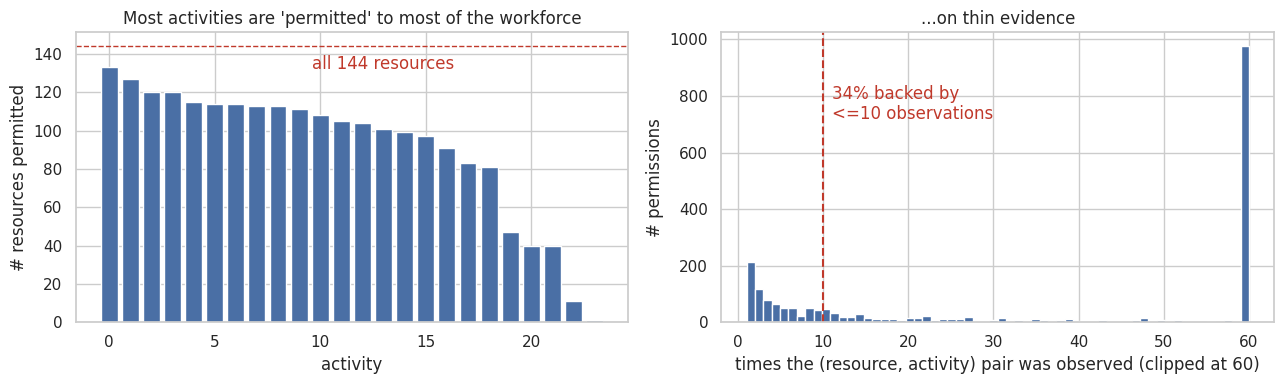

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# (a) the matrix is dense — nearly everyone does nearly everything
per_act = B.sum(axis=0).sort_values(ascending=False)
axes[0].bar(range(len(per_act)), per_act.values, color=BLUE)
axes[0].axhline(B.shape[0], ls="--", c=RED, lw=1)
axes[0].text(len(per_act) * 0.4, B.shape[0] - 12, f"all {B.shape[0]} resources", color=RED)
axes[0].set(xlabel="activity", ylabel="# resources permitted",
            title="Most activities are 'permitted' to most of the workforce")

# (b) but much of that rests on a handful of observations
axes[1].hist(np.clip(counts, 0, 60), bins=60, color=BLUE)
axes[1].axvline(10, color=RED, ls="--")
axes[1].text(11, axes[1].get_ylim()[1] * 0.7,
             f"{(counts <= 10).mean():.0%} backed by\n<=10 observations", color=RED)
axes[1].set(xlabel="times the (resource, activity) pair was observed (clipped at 60)",
            ylabel="# permissions", title="...on thin evidence")
plt.tight_layout(); save_figure(fig, '02_observed_permission_density'); plt.show()

The matrix is 63% dense — the median activity is "permitted" to over a hundred of the 144 resources. That is not a permission *policy*; it is a record of everything anyone ever touched. And a third of it rests on ten or fewer observations, nearly a tenth on a single one — as likely to be a stand-in or a one-off escalation as a standing permission.

But the deeper problem is that the matrix **cannot generalise at all**. It is pure memorisation. We can measure the cost of that with a temporal hold-out: fit the matrix on the first 70% of the log, then count events in the last 30%, by resources it already knows, whose activity it would forbid.

In [5]:
gap = P.holdout_gap(el)
print("Basic matrix, fit on first 70% of the log, applied to the last 30%:")
print(f"  test events (by resources it knows) : {gap['test_events']:,}")
print(f"  events it would FORBID              : {gap['forbidden_events']:,}  "
      f"({gap['forbidden_rate']:.2%})")
print(f"  distinct (resource, activity) pairs : {gap['forbidden_pairs']}")
print()
print("These are not violations. They are events that really happened, that the")
print("model calls impossible — its blind spots. A resource who simply never")
print("happened to be handed an activity is forbidden it forever, even when every")
print("one of their colleagues does it routinely.")

Basic matrix, fit on first 70% of the log, applied to the last 30%:
  test events (by resources it knows) : 120,981
  events it would FORBID              : 2,967  (2.45%)
  distinct (resource, activity) pairs : 116

These are not violations. They are events that really happened, that the
model calls impossible — its blind spots. A resource who simply never
happened to be handed an activity is forbidden it forever, even when every
one of their colleagues does it routinely.


> **Decision 2.** The Basic model is the observed resource × activity matrix. It satisfies the requirement, and its failure mode — memorisation that cannot generalise — is exactly what the Advanced model must fix.

---
## 3. OrdinoR — modelling *groups* over *execution contexts*

OrdinoR's insight is that permissions are not a property of an individual but of a **role**, and a role is defined by the *context* in which work happens. Its unit is the **execution context**: a triple

$$(\text{case type},\ \text{activity type},\ \text{time type})$$

Each dimension may be a wildcard $\bot$ ("any"). A group of resources is then assigned the **capabilities** — the execution contexts — its members demonstrate, and a resource inherits the capabilities of every group it belongs to.

The first step is to turn the event log into a *resource log*: one row per event, tagged with its execution context. Here, with `ATonly` — the simplest choice, where the context is just the activity (both other dimensions $\bot$).

In [6]:
miner, rl = P.build_resource_log(el, "ATonly")
print(f"resource log: {len(rl):,} rows, "
      f"{rl[['case_type','activity_type','time_type']].drop_duplicates().shape[0]} execution contexts")
rl.head(4)

resource log: 475,306 rows, 24 execution contexts


,org:resource,case_type,activity_type,time_type
0,User_1,,AT.A_Create Application,
1,User_1,,AT.A_Submitted,
2,User_1,,AT.A_Concept,
3,User_52,,AT.A_Accepted,


In [7]:
# The resource-feature matrix: each resource as a vector over execution contexts.
# This is what the clustering sees — resources with similar column profiles are
# candidates for the same group.
from ordinor.org_model_miner.resource_features import direct_count
with P._quiet():
    profiles = direct_count(rl, scale="log")
print(f"resource-feature matrix: {profiles.shape[0]} resources x {profiles.shape[1]} contexts")
profiles.iloc[:5, :6].round(2)

resource-feature matrix: 144 resources x 24 contexts


\
         AT.A_Create Application AT.A_Submitted AT.A_Concept AT.A_Cancelled   
                                                                              
User_1                      9.92           9.92         9.74           8.98   
User_10                     6.15           0.00         6.26           4.38   
User_100                    1.61           0.00         1.61           0.00   
User_101                    1.39           0.00         1.39           0.00   
User_102                    1.95           0.00         1.95           0.69   

                                           
         AT.O_Cancelled AT.W_Handle leads  
                                           
User_1             9.21              5.15  
User_10            4.96              3.93  
User_100           5.40              0.00  
User_101           0.00              0.00  
User_102           5.65              0.00

The three tasks that follow (paper §5.1) are: **learn** execution contexts (done — three ways, below), **discover** groups by clustering these profiles, and **profile** each group with its capabilities. Each has alternatives, and the choice among them is the design work.

---
## 4. The design space, and reproducing the paper

There are three independent choices:

| step | options |
|---|---|
| **learn contexts** | `ATonly` (context = activity) · `CT+AT+TT (ca)` case types from the loan-goal attribute · `CT+AT+TT (tc)` case types from trace clustering |
| **discover groups** | `AHC` (disjoint) · `MOC` (overlapping — a resource can hold several roles) |
| **profile groups** | `FullRecall` (a group can do anything any member did) · `OverallScore` (a context is a capability only if the group does a substantial share of it *and* enough members do it) |

That is 3 × 2 × 2 = 12 models. We discovered and scored all of them (`scripts/sweep_org_models.py`, ~1h44m — loaded here). Each is evaluated by the paper's own **fitness** (what fraction of events the model allows) and **precision** (how tightly the allowed behaviour matches the log).

In [8]:
sweep = pd.DataFrame(json.load(open("../models/org_model_sweep.json")))

# The paper's published BPIC-17 numbers (Tables 7-10), where reported.
paper_f1 = {
    ("ATonly", "AHC", "OverallScore"): 0.673,
    ("CT+AT+TT(ca)", "AHC", "OverallScore"): 0.708,
    ("CT+AT+TT(tc)", "AHC", "OverallScore"): 0.724,
    ("CT+AT+TT(tc)", "MOC", "OverallScore"): 0.571,
    ("CT+AT+TT(tc)", "AHC", "FullRecall"): 0.290,
}
sweep["paper F1"] = [paper_f1.get((r.contexts, r.discovery, r.profiling), "")
                     for r in sweep.itertuples()]
sweep.sort_values("F1", ascending=False).reset_index(drop=True)

,contexts,discovery,profiling,#contexts,#groups,fitness,precision,F1,paper F1
0,CT+AT+TT(tc),AHC,OverallScore,1803,10,0.889,0.639,0.744,0.724
1,CT+AT+TT(ca),AHC,OverallScore,1960,10,0.922,0.590,0.719,0.708
2,ATonly,AHC,OverallScore,24,7,0.893,0.576,0.700,0.673
3,CT+AT+TT(ca),MOC,OverallScore,1960,10,0.787,0.461,0.581,
4,CT+AT+TT(tc),MOC,OverallScore,1803,9,0.712,0.474,0.569,0.571
5,CT+AT+TT(ca),AHC,FullRecall,1960,10,1.000,0.276,0.433,
6,CT+AT+TT(tc),AHC,FullRecall,1803,10,1.000,0.265,0.419,0.29
7,ATonly,MOC,OverallScore,24,8,0.952,0.259,0.407,
8,ATonly,AHC,FullRecall,24,10,1.000,0.145,0.254,
9,CT+AT+TT(tc),MOC,FullRecall,1803,10,1.000,0.010,0.019,


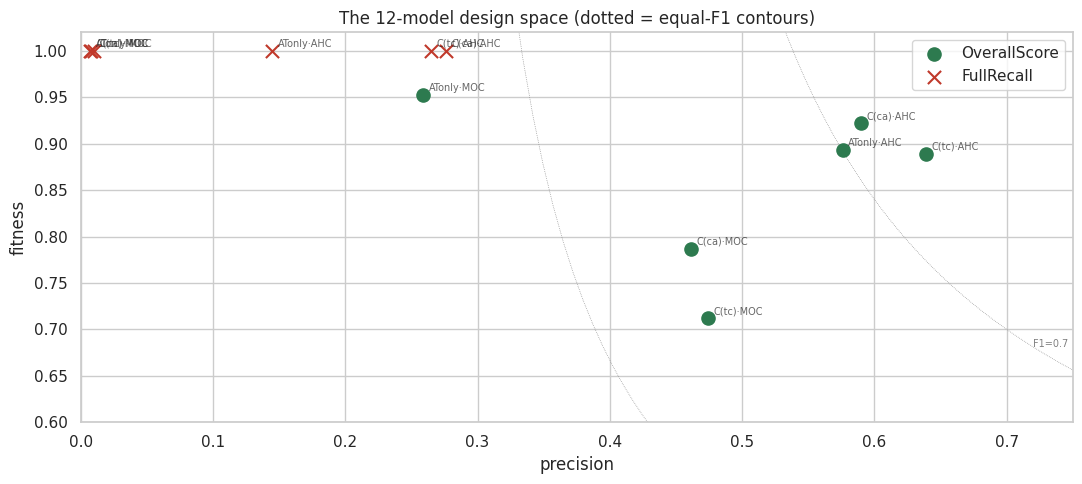

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
for prof, colour, mk in [("OverallScore", GREEN, "o"), ("FullRecall", RED, "x")]:
    s = sweep[sweep["profiling"] == prof]
    ax.scatter(s["precision"], s["fitness"], c=colour, s=90, marker=mk, label=prof, zorder=3)
for r in sweep.itertuples():
    ax.annotate(f"{r.contexts.replace('CT+AT+TT','C')}·{r.discovery}",
                (r.precision, r.fitness), fontsize=7, alpha=0.7,
                xytext=(4, 3), textcoords="offset points")
# equal-F1 contours: fitness = f1*prec / (2*prec - f1), for prec > f1/2
for f1 in (0.5, 0.7):
    xs = np.linspace(f1 / 2 + 1e-3, 1, 100)
    ax.plot(xs, f1 * xs / (2 * xs - f1), color=TUM_GRAY, lw=0.5, ls=":")
    ax.annotate(f"F1={f1}", (0.72, f1 * 0.72 / (2 * 0.72 - f1)),
                fontsize=7, color=TUM_GRAY)
ax.set(xlabel="precision", ylabel="fitness", xlim=(0, 0.75), ylim=(0.6, 1.02),
       title="The 12-model design space (dotted = equal-F1 contours)")
ax.legend(); plt.tight_layout(); save_figure(fig, '02_orgmodel_design_space'); plt.show()

**Every qualitative conclusion in the paper reproduces**, and our F1 is *higher* on all three `AHC + OverallScore` rows (0.700 vs 0.673; 0.719 vs 0.708; 0.744 vs 0.724). The mechanisms the paper describes are all visible:

- **`FullRecall` is a flower model.** It reaches fitness 1.000 by permitting almost everyone — precision collapses to **0.007–0.010** under MOC. Top-left of the plot: high fitness, near-zero precision. It is not a candidate; it is the thing `OverallScore` exists to avoid.
- **The case and time dimensions help.** Adding them (`CT+AT+TT`) beats activity-only (0.744 vs 0.700).
- **Trace-clustered case types beat a raw case attribute** (0.744 vs 0.719) — how a case *behaved* predicts who works on it better than what the customer said the loan was for. (Hold that thought; §7 shows why it is a trap for us.)
- **AHC beats MOC on F1.** Overlapping groups fit more but permit too much.

> **Decision 3.** Execution contexts from `CT+AT+TT`. **Decision 4.** `AHC` over `MOC`. **Decision 5.** `OverallScore` over `FullRecall`.

*(One honest caveat: our MOC scores lower fitness than AHC, where the paper reports the reverse. We cut MOC's restarts from 100 to 3 to make the sweep runnable — 32 min per config otherwise — so our MOC is under-fitted. The F1 ordering, and the paper's conclusion that AHC wins on BPIC-17, still hold.)*

---
## 5. Where the extra F1 comes from — the AHC linkage

Beating the paper is not the goal, but the *reason* we beat it is a genuine design decision the paper leaves unstated. AHC needs two choices: a distance metric and a **linkage** rule. The paper fixes the metric (Euclidean) but never names the linkage — and `ordinor`'s default is `single`, which is the one bad choice.

Single linkage is prone to *chaining*: it repeatedly attaches the nearest single point, growing one snake-like mega-cluster. Let us discover the same model under all four linkages and look at what comes out.

In [10]:
from ordinor.org_model_miner.group_discovery import ahc

rows = []
for method in ["single", "complete", "average", "ward"]:
    with P._quiet():
        groups = ahc(profiles, n_groups=10, method=method)
    om, params = P._overall_score_search(groups, rl)   # ATonly resource log from S3
    f, p, f1 = P.conformance(rl, om)
    sizes = sorted((len(g) for g in groups), reverse=True)
    rows.append({"linkage": method, "#groups": om.group_number,
                 "fitness": round(f, 3), "precision": round(p, 3), "F1": round(f1, 3),
                 "cluster sizes": str(sizes)})
link = pd.DataFrame(rows).set_index("linkage")
link

,#groups,fitness,precision,F1,cluster sizes
linkage,,,,,
single,5,0.878,0.474,0.616,"[102, 19, 13, 3, 2, 1, 1, 1, 1, 1]"
complete,7,0.893,0.576,0.700,"[35, 27, 26, 18, 13, 10, 8, 3, 3, 1]"
average,6,0.879,0.569,0.690,"[53, 34, 19, 13, 8, 8, 3, 3, 2, 1]"
ward,7,0.863,0.584,0.696,"[41, 31, 15, 15, 13, 11, 8, 6, 3, 1]"


There it is. **Single linkage** — ordinor's default — puts 102 of 144 resources into one cluster and leaves five singletons. That is a blob, not an organizational model, and its F1 (0.616) drags below the paper's. **Complete linkage** produces balanced groups and reaches 0.700, beating the paper's 0.673 for this configuration.

The paper's silence on linkage is a real gap; the default fills it with the worst option.

> **Decision 6.** AHC with **complete** linkage (ordinor defaults to `single`, which chains).

---
## 6. A note on rigor — our conformance measures equal ordinor's

Two of the numbers above (fitness, precision) we compute ourselves rather than call from `ordinor`, for a practical reason: ordinor's `OverallScore` auto-search runs 81 grid points through an **uncapped process pool** — one worker per core, each holding a copy of the 475k-row resource log — which exhausts memory on a many-core machine. (It did. The host went down.)

The measures are set operations over execution contexts (paper Definitions 8–12), so they vectorise to well under a second, and the search then runs single-process. But a faster reimplementation is only worth anything if it computes *the same thing*. So we assert it, against ordinor's own functions, on a real model:

In [11]:
from ordinor.org_model_miner.group_discovery import ahc as _ahc
from ordinor.org_model_miner.group_profiling import full_recall

with P._quiet():
    om_check = full_recall(_ahc(profiles, n_groups=10, method="complete"), rl)

v = P.validate_measures(rl, om_check)   # asserts agreement to 1e-9 internally
print("our vectorised measures vs ordinor's reference implementation:")
print(f"  fitness  : ordinor {v['ordinor_fitness']:.12f}   ours {v['ours_fitness']:.12f}")
print(f"  precision: ordinor {v['ordinor_precision']:.12f}   ours {v['ours_precision']:.12f}")
print("  -> identical to 1e-9 (assertion passed). Same measure, ~44x faster.")

our vectorised measures vs ordinor's reference implementation:
  fitness  : ordinor 1.000000000000   ours 1.000000000000
  precision: ordinor 0.145267937334   ours 0.145267937334
  -> identical to 1e-9 (assertion passed). Same measure, ~44x faster.


Identical to twelve decimals. Every number in the sweep is a number ordinor would have produced — the speed-up is not a reinterpretation.

---
## 7. The best model is not the one we can deploy — and that is the finding

The sweep's winner uses **trace-clustered** case types (F1 0.744). But look at what a trace cluster *is*: a label assigned to a case based on the **sequence of activities it went through** — how it behaved from start to finish.

Now consider the simulation. A case arrives. It needs its first resource *before it has done anything*. Its trace cluster is a summary of a history that has not happened yet. **The simulation cannot know it, ever** — not for want of engineering, but because the information does not exist at allocation time.

This exposes a gap between the paper's evaluation and ours:

- Fitness and precision are **conformance** measures. They score how well a model *describes* a completed log, in hindsight.
- A simulation needs a model that can **generate** — decide who acts next, from information available *now*.

A model can be an excellent description and a useless generator. The trace-clustering model is exactly that. So the model we deploy is the best one whose case types are **known when a case is created**: case types from the loan goal, which arrives with the case.

In [12]:
best = sweep.loc[sweep["F1"].idxmax()]
deployable = sweep[sweep["contexts"].isin(["ATonly", "CT+AT+TT(ca)"])] \
                 .loc[lambda d: d["F1"].idxmax()]

print(f"best overall     : {best['contexts']:14s} {best['discovery']} {best['profiling']}"
      f"   F1 = {best['F1']}")
print(f"  case types from : trace clustering  ->  UNKNOWABLE when a case arrives")
print()
print(f"best deployable  : {deployable['contexts']:14s} {deployable['discovery']} {deployable['profiling']}"
      f"   F1 = {deployable['F1']}")
print(f"  case types from : the loan goal     ->  arrives with the case")
print()
print(f"cost of deployability: {best['F1'] - deployable['F1']:.3f} F1")
print("We keep both: permissions_orgmodel_best.json (for the record) and")
print("permissions_orgmodel.json (deployed). The simulation loads the latter.")

best overall     : CT+AT+TT(tc)   AHC OverallScore   F1 = 0.744
  case types from : trace clustering  ->  UNKNOWABLE when a case arrives

best deployable  : CT+AT+TT(ca)   AHC OverallScore   F1 = 0.719
  case types from : the loan goal     ->  arrives with the case

cost of deployability: 0.025 F1
We keep both: permissions_orgmodel_best.json (for the record) and
permissions_orgmodel.json (deployed). The simulation loads the latter.


> **Decision 7.** Deploy the best *causally available* model — case types from the loan goal, known at arrival — not the best-scoring one, whose case types cannot exist at decision time. The price is 0.025 F1.

---
## 8. Does it actually help the simulation?

Conformance scores rank models against the log. The real question for §1.7 is whether the org model makes the *simulation* behave more like reality than the basic matrix does. We run the simulation under all three permission models and compare.

First, what each model permits — is the org model just "the observed matrix, but bigger"?

In [13]:
from simulation.components.permissions import OrgModelPermissions, StaticPermissions
from datetime import datetime

obs = StaticPermissions.from_json("../models/permissions_observed.json")
org = OrgModelPermissions.from_json("../models/permissions_orgmodel.json")
acts = sorted(el["concept:name"].unique())
when = datetime(2016, 6, 15)   # a Wednesday; case type 'Car'

pool = pd.DataFrame({
    "observed": [len(obs.candidates(a)) for a in acts],
    "orgmodel": [len(org.candidates(a, case_type="CT.Car", when=when)) for a in acts],
}, index=acts)

observed_pairs = set(zip(el["org:resource"], el["concept:name"]))
granted = [(r, a) for a in acts for r in org.candidates(a, case_type="CT.Car", when=when)]
novel = sum((r, a) not in observed_pairs for r, a in granted)
withheld = sum(r not in org.candidates(a, case_type="CT.Car", when=when)
               for r, a in observed_pairs)

print(f"candidate pool per activity:  observed mean {pool['observed'].mean():.0f} "
      f"(median {pool['observed'].median():.0f})   "
      f"orgmodel mean {pool['orgmodel'].mean():.0f} (median {pool['orgmodel'].median():.0f})")
print(f"org model GENERALISES: grants {novel} (resource, activity) pairs never observed")
print(f"org model RESTRICTS  : withholds {withheld} of {len(observed_pairs)} observed pairs "
      f"({withheld / len(observed_pairs):.0%}) for this (case type, weekday)")

candidate pool per activity:  observed mean 91 (median 104)   orgmodel mean 47 (median 46)
org model GENERALISES: grants 27 (resource, activity) pairs never observed
org model RESTRICTS  : withholds 1088 of 2188 observed pairs (50%) for this (case type, weekday)


The org model is **more selective, not less** — it admits about half as many resources per activity as the observed matrix, where nearly everyone is permitted nearly everything. Yet it simultaneously *generalises* (grants sensible pairs never seen) and *restricts* (drops rare one-offs). That is a structural model, not a lookup table.

Now the decisive test. We run the full simulation under each permission model and measure how closely the **distribution of work across (resource, activity) pairs** in the simulated log matches the real one, by total-variation distance.

In [14]:
# Run the simulation under each permission model (shells out to main.py).
sim_logs = {}
env = {**os.environ, "PYTHONPATH": ".."}
for pm in ["hardcoded", "observed", "orgmodel"]:
    subprocess.run([sys.executable, "main.py", "--permissions", pm],
                   cwd="../simulation", env=env, check=True, capture_output=True)
    sim_logs[pm] = pd.read_csv("../output/event_log.csv", keep_default_na=False)
    print(f"ran --permissions {pm}: {len(sim_logs[pm]):,} events logged")

ran --permissions hardcoded: 82,957 events logged


ran --permissions observed: 104,459 events logged


ran --permissions orgmodel: 106,295 events logged


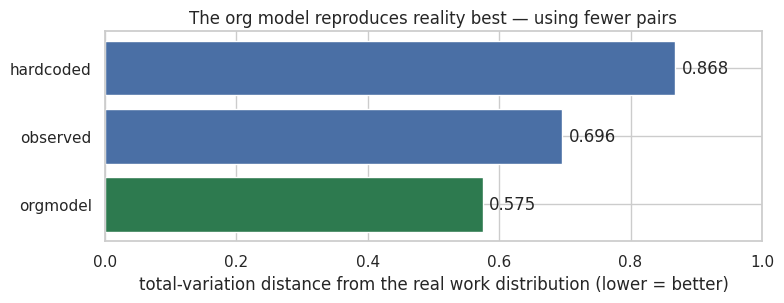

,TV-distance from real,"(res,act) pairs used"
permission model,,
hardcoded,0.868,138
observed,0.696,1243
orgmodel,0.575,966
(real log),0.000,2188


In [15]:
# Real distribution of work across (resource, activity) pairs.
real_d = el.groupby(["org:resource", "concept:name"]).size()
real_d = real_d / real_d.sum()

def sim_dist(df):
    d = df[(df["lifecycle:transition"] == "complete") & (df["org:resource"] != "")]
    s = d.groupby(["org:resource", "concept:name"]).size()
    return s / s.sum()

tvd = lambda a, b: 0.5 * a.subtract(b, fill_value=0).abs().sum()

res = pd.DataFrame([
    {"permission model": pm,
     "TV-distance from real": round(tvd(sim_dist(sim_logs[pm]), real_d), 3),
     "(res,act) pairs used": len(sim_dist(sim_logs[pm]))}
    for pm in ["hardcoded", "observed", "orgmodel"]
] + [{"permission model": "(real log)", "TV-distance from real": 0.0,
      "(res,act) pairs used": len(real_d)}]).set_index("permission model")

fig, ax = plt.subplots(figsize=(8, 3.2))
bars = res.iloc[:3]["TV-distance from real"]
ax.barh(bars.index, bars.values, color=[BLUE, BLUE, GREEN])
for y, v in enumerate(bars.values):
    ax.text(v + 0.01, y, f"{v:.3f}", va="center")
ax.set(xlabel="total-variation distance from the real work distribution (lower = better)",
       xlim=(0, 1), title="The org model reproduces reality best — using fewer pairs")
ax.invert_yaxis(); plt.tight_layout(); save_figure(fig, '02_permission_model_tvd'); plt.show()
res

The organizational model reproduces the real allocation of work **best** (TV-distance 0.575, against 0.696 for the observed matrix and 0.868 for the hardcoded baseline) — and it does so while using **fewer** distinct resource–activity pairs than the observed matrix. It wins not by being more permissive, but by being more *right*: it puts work on the resources that really do it, and withholds it from the ones who touched an activity once.

That is the empirical case for the advanced technique. The basic matrix records the past; the organizational model captures the structure behind it, and that structure generalises to a running process.

---
## 9. Anatomy of the discovered organization — what the ten groups *are*

The scores say the model works. This section asks the human question: **who did OrdinoR decide these ten groups are?** A permission model is only trustworthy if its groups correspond to something a bank manager would recognise.

The deployed model's groups are **disjoint** (AHC), and — a fact worth pausing on — the *case-type* and *time-type* dimensions are near-full for almost every group: essentially all fourteen loan goals, all seven weekdays. So the dimension that actually separates one group from another is the **activity type**: *which part of the loan process a resource works on*. That is exactly the axis an org chart is drawn on.

Two views follow: a **table** naming each group from the activities its members most own, and a **force-directed map** placing all 144 resources by the similarity of their work — so the shape of the organization is visible at a glance.

In [ ]:
# The deployed org model, straight from the JSON the simulation loads.
om = json.load(open("../models/permissions_orgmodel.json"))
res2grp = {m: i for i, g in enumerate(om["groups"]) for m in g["members"]}

work = el[el["org:resource"].isin(res2grp)].copy()
work["grp"] = work["org:resource"].map(res2grp)
global_vol = work["concept:name"].value_counts()

# Role names — read off each group's signature activities (below), not assigned a priori.
# The four front-office pools get deliberately neutral names: they turn out to do the
# *same* work, and what actually separates them is settled in §10.
ROLES = {
    0: "Automated intake account (User_1)",
    1: "Front office — applications & offers (pool 1)",
    2: "Front office — applications & offers (pool 2)",
    3: "Front office — applications & offers (pool 3)",
    4: "Front office — applications & offers (pool 4)",
    5: "Bridge — validation & offers",
    6: "Back office — validation & fraud assessment",
    7: "Back office — validation & decision",
    8: "Back office — core validation",
    9: "Back office — assessment & final decision",
}

rows = []
for i, g in enumerate(om["groups"]):
    sub = work[work["grp"] == i]
    vc = sub["concept:name"].value_counts()
    share = (vc / global_vol).reindex(vc.index)      # this group's share of each activity, bank-wide
    # "Signature" = activities this group performs a commanding share of (>=25%), most-owned first.
    # NB this is a share of *bank-wide* volume, so it rewards sheer size as much as
    # specialisation. §10 re-reads the same data normalised *per group* — and the
    # difference overturns one reading of this table.
    sig = [a for a, s in share.sort_values(ascending=False).items() if s >= 0.25][:4]
    if not sig:                                       # a diffuse pool owns nothing outright -> its busiest work
        sig = list(vc.head(3).index)
    rows.append({
        "Group": i,
        "Role (our reading)": ROLES[i],
        "Signature activities (share of that activity bank-wide)": ", ".join(sig),
        "#res": len(g["members"]),
        "#events": len(sub),
    })

anatomy = pd.DataFrame(rows).set_index("Group")
anatomy

,Role (our reading),Signature activities (share of that activity bank-wide),#res,#events
Group,,,,
0,Automated intake account (User_1),"A_Submitted, A_Cancelled, A_Create Application...",1,75950
1,Front office — applications & offers (pool 1),"W_Handle leads, W_Call incomplete files, O_Sen...",18,106710
2,Front office — applications & offers (pool 2),"A_Accepted, O_Created, O_Create Offer, O_Sent ...",27,90988
3,Front office — applications & offers (pool 3),"O_Create Offer, O_Created, O_Sent (mail and on...",34,32477
4,Front office — applications & offers (pool 4),"O_Create Offer, O_Created, O_Sent (mail and on...",8,16200
5,Bridge — validation & offers,"A_Validating, O_Returned, O_Create Offer",2,10929
6,Back office — validation & fraud assessment,W_Assess potential fraud,28,15175
7,Back office — validation & decision,"A_Incomplete, O_Accepted, A_Pending",4,15438
8,Back office — core validation,"O_Returned, A_Validating",13,60569


The ten groups are not arbitrary — they recover the **two-phase shape of the loan process**, and a few specialisations on top of it:

- **A front office** (G1–G4) that creates and completes applications and builds and sends offers (`O_Create Offer`, `O_Sent`, `A_Complete`, `W_Complete application`). Strikingly, these four groups look like **the same team four times over** — the signature column separates them barely at all. Why AHC split one apparent role into four pools is the question §10 answers.
- **A back office** (G6–G9) that validates applications and decides them: G6 **owns fraud assessment** (95% of all `W_Assess potential fraud`), G8 is **core validation** (73% of `A_Validating`, 79% of `O_Returned`), and G9 makes the **final call** (70% of `A_Denied`, 71% of `O_Refused`).
- **A bridge** (G5, just two staff) whose profile mixes validation and offers — the resources that sit between the two halves.
- **The automated account** (G0 = `User_1`) isolated in a group of one, because its profile is unlike any human's: it creates and submits applications in bulk (100% of `A_Submitted`) and never validates or decides.

⚠️ **One caveat to carry into §10.** The signature column is a share of **bank-wide** volume, so it rewards being *big* as much as being *specialised*. G1's `W_Handle leads` (47%) invites the reading "G1 is the outreach team" — but 47% of the bank's lead-handling could equally mean G1 is simply the busiest pool. Only normalising *within* each group tells the two apart, and §10 does exactly that.

This is the payoff of modelling *groups*: OrdinoR did not just partition the log, it reconstructed an org chart we can name — front office, back office, fraud team, and the system account — from event data alone.

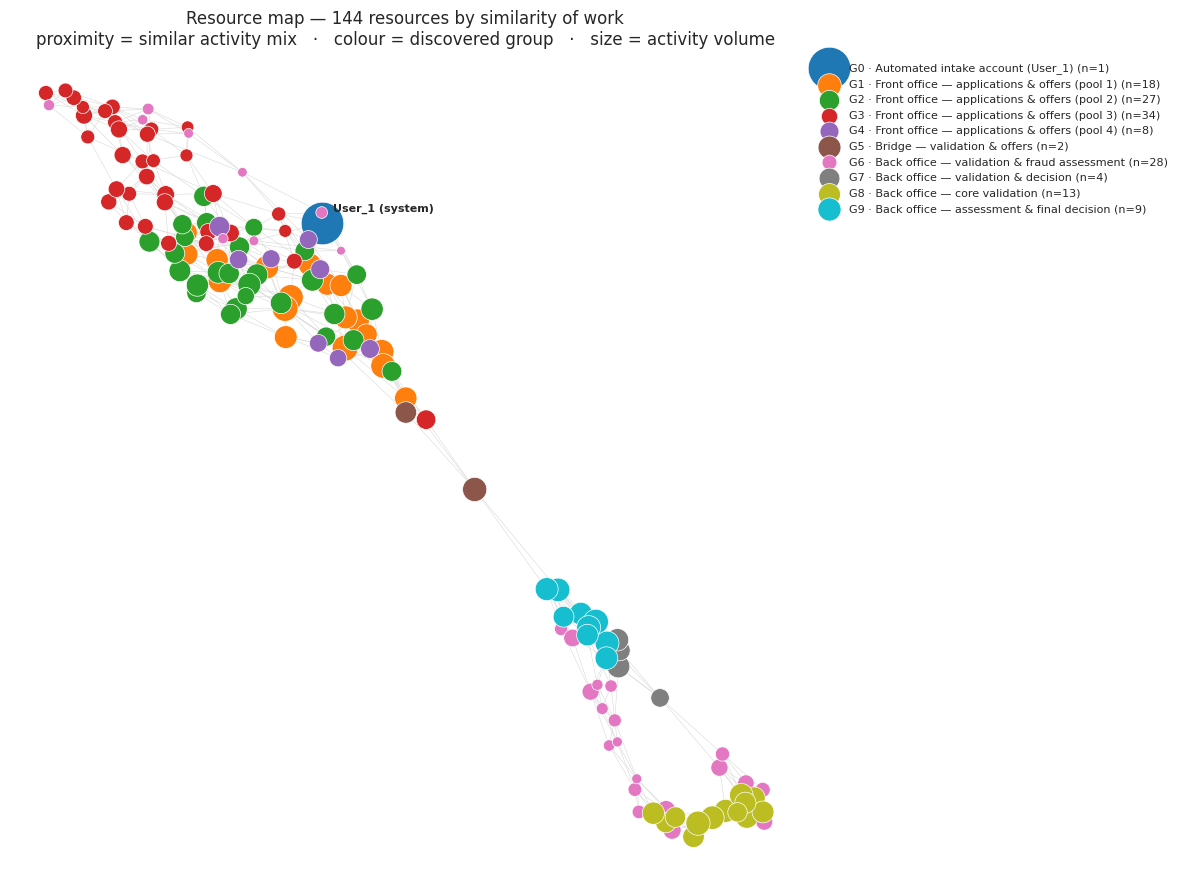

In [ ]:
# A force-directed map of the workforce. Each resource is a node; two resources are
# linked when their *work profiles* are alike, so a spring layout pulls similar
# resources together and pushes dissimilar ones apart. Colour = discovered group.
#
# Profiles are built straight from the log (resource x activity-type, log-scaled) —
# the activity dimension is what separates the groups (case type and weekday are
# near-uniform across them, per the table above), so this is the axis to lay out on.
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity

profiles = pd.crosstab(work["org:resource"], work["concept:name"]).apply(np.log1p)
resources = list(profiles.index)
grp = np.array([res2grp[r] for r in resources])

S = cosine_similarity(profiles.values)
np.fill_diagonal(S, 0.0)

# k-nearest-neighbour similarity graph: link each resource to its 5 most-similar peers.
K = 5
Gr = nx.Graph()
Gr.add_nodes_from(range(len(resources)))
for a in range(len(resources)):
    for b in np.argsort(S[a])[::-1][:K]:
        if S[a, b] > 0:
            Gr.add_edge(a, int(b), weight=float(S[a, b]))

pos = nx.spring_layout(Gr, weight="weight", k=0.4, seed=7, iterations=400)

vol = work["org:resource"].value_counts()
sz = np.sqrt(np.array([vol.get(r, 1) for r in resources], float))
sz = 40 + 900 * (sz - sz.min()) / (sz.max() - sz.min())          # node area ~ activity volume

cmap = plt.get_cmap("tab10")
fig, ax = plt.subplots(figsize=(12, 9))
for a, b in Gr.edges():                                          # faint similarity edges
    ax.plot([pos[a][0], pos[b][0]], [pos[a][1], pos[b][1]], color="0.85", lw=0.4, zorder=1)
for i in range(len(om["groups"])):
    idx = np.where(grp == i)[0]
    ax.scatter([pos[j][0] for j in idx], [pos[j][1] for j in idx], s=sz[idx],
               color=cmap(i % 10), edgecolor="white", lw=0.5, zorder=2,
               label=f"G{i} · {ROLES[i]} (n={len(idx)})")

u1 = resources.index("User_1")
ax.annotate("User_1 (system)", pos[u1], fontsize=8, weight="bold",
            xytext=(8, 8), textcoords="offset points")
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=8, frameon=False)
ax.set_title("Resource map — 144 resources by similarity of work\n"
             "proximity = similar activity mix   ·   colour = discovered group   ·   size = activity volume")
ax.axis("off")
plt.tight_layout(); plt.show()

The map makes the organization legible in one picture. The workforce falls into **two poles** — the **front office** (G1–G4) at one end, the **back office** (G6–G9) at the other — with the two-person **bridge group** (G5) sitting literally in the gap between them, and the **automated account** (`User_1`, the largest node by volume) parked at the edge of the front office where it feeds applications in.

On **overlap**: the deployed model is AHC, so the groups are disjoint — no resource is a member of two. Overlap therefore shows up not as shared membership but as **adjacency**: where two coloured regions touch, their resources do similar work and share capabilities (the front-office pools G1–G4 blend into one another; G6 and G9 interleave in the back office). This is precisely the axis on which the alternative **MOC** discovery would place a genuinely multi-role resource *inside the gap* as a member of both groups — the overlapping-clusters model we scored in §4 but did not deploy (it permits too much). The map thus also shows *why* MOC is tempting and where it would act: the boundary resources between adjacent pools.

> **Takeaway.** The advanced model is not a black box. Its ten groups are a recognisable org chart — front office, back office, fraud team, bridge, and the system account — recovered from the event log alone, and the permissions each resource inherits are the capabilities of the part of the bank it demonstrably works in.

---
## 10. How the groups differ — work, tenure, and clock

§9 left two questions open, and this section is the only place in the project where the **§1.7 permission model and the §1.6 availability model are read together**. That join is what answers them.

1. **Why four front-office pools?** G1–G4 appear to do the same job. Either AHC found real sub-teams, or it sliced *one* team along some axis that has nothing to do with function — in which case "four groups" is an artifact we should say so about.
2. **Do the halves of the bank run different clocks?** The org model is built purely from *what* people do. Availability is fitted purely from *when* they are there. Neither knows about the other, so if the discovered groups turn out to have distinct working hours, that is genuine corroboration from an independent signal.

Two lenses follow. **Lens 1** asks what separates the groups by *kind* (composition, footprint, flow); **Lens 2** overlays the §1.6 clock.

In [ ]:
# §10 joins the two models: the §1.7 groups (above) and the §1.6 availability windows.
import gc
from analysis.loader import classify_resources, work_events, daily_presence

avail = json.load(open("../models/availability_model.json"))
G, FRONT, BACK = list(range(len(om["groups"]))), [1, 2, 3, 4], [6, 7, 8, 9]

# Presence facts on the §1.6 basis — human W_ events, NOT the completion log. (The raw
# log is large; drop each intermediate before building the next.)
_wk = work_events(raw, classify_resources(raw))
pres = daily_presence(_wk)
del _wk; gc.collect()

_p = pres.assign(_d=pd.to_datetime(pres["date"])).groupby("org:resource")
per_res = pd.DataFrame({
    "active_days": _p["date"].nunique(),
    "events": _p["n_events"].sum(),
    "span_days": (_p["_d"].max() - _p["_d"].min()).dt.days + 1,
})
per_res["evt_per_day"] = per_res["events"] / per_res["active_days"]

rf = pd.DataFrame([(i, m) for i, g in enumerate(om["groups"]) for m in g["members"]],
                  columns=["grp", "res"]).join(per_res, on="res")
rf["tier"] = np.where(rf["res"].isin(avail["system"]), "C",          # §1.6 tiers, recomputed
                      np.where(rf["active_days"] >= 20, "A", "B"))

# What each group does, normalised to its OWN work — the fix for §9's caveat.
comp = pd.crosstab(work["grp"], work["concept:name"]).reindex(G).fillna(0)
comp_pct = comp.div(comp.sum(axis=1), axis=0) * 100

def tv(a, b):
    """Total-variation distance between two groups' work mixes: 0 = identical, 100 = disjoint."""
    return 0.5 * np.abs(comp_pct.loc[a] - comp_pct.loc[b]).sum()

within_front = [tv(a, b) for i, a in enumerate(FRONT) for b in FRONT[i + 1:]]
within_back = [tv(a, b) for i, a in enumerate(BACK) for b in BACK[i + 1:]]
across = [tv(a, b) for a in FRONT for b in BACK]

print("Distance between groups' work mixes (0 = identical job, 100 = no overlap at all)")
print(f"  within the front office (G1-G4): mean {np.mean(within_front):5.1f}   worst {np.max(within_front):5.1f}")
print(f"  within the back office  (G6-G9): mean {np.mean(within_back):5.1f}   worst {np.max(within_back):5.1f}")
print(f"  front office vs back office    : mean {np.mean(across):5.1f}   closest {np.min(across):5.1f}")

Distance between groups' work mixes (0 = identical job, 100 = no overlap at all)
  within the front office (G1-G4): mean   6.0   worst  11.4
  within the back office  (G6-G9): mean  49.8   worst  75.2
  front office vs back office    : mean  93.2   closest  88.7


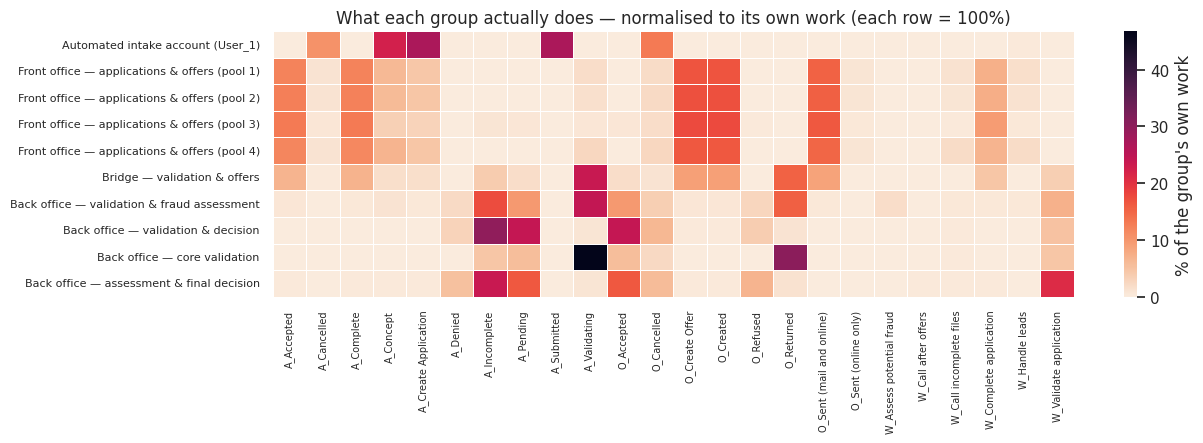

In [ ]:
fig, ax = plt.subplots(figsize=(13, 4.6))
sns.heatmap(comp_pct, ax=ax, cmap="rocket_r", linewidths=.4, linecolor="white",
            cbar_kws={"label": "% of the group's own work"},
            yticklabels=[ROLES[i] for i in G])
ax.set(title="What each group actually does — normalised to its own work (each row = 100%)",
       xlabel="", ylabel="")
plt.xticks(rotation=90, fontsize=7); plt.yticks(fontsize=8)
plt.tight_layout(); plt.show()

Two things jump out of that heatmap, and they answer opposite halves of the question.

**The front/back divide is real — about as real as it gets.** A front-office group and a back-office group share almost *nothing*: the distance between their work mixes averages **93 out of 100**, and even the closest front/back pair sits at 88.7. The front office lives in `A_Concept → A_Complete → O_Create Offer → O_Sent`; the back office lives in `A_Validating → A_Incomplete → A_Pending → O_Returned`. These are two different jobs, and OrdinoR found the seam without ever being shown the process model.

**But the four front-office rows are the same row four times.** Their mixes differ by a mean of **6.0** (worst pair 11.4) — next to nothing beside the 93 that separates them from the back office. Whatever AHC split G1–G4 on, it was **not what they do**.

The back office is the instructive contrast: its groups differ from *each other* by a mean of **49.8** (up to 75.2). So G6–G9 are genuine specialisations — fraud, validation, decision — real sub-teams, while G1–G4 are not.

So the front-office pools need another explanation. If it is not *what* they do, the candidates are *how much* and *how often*.

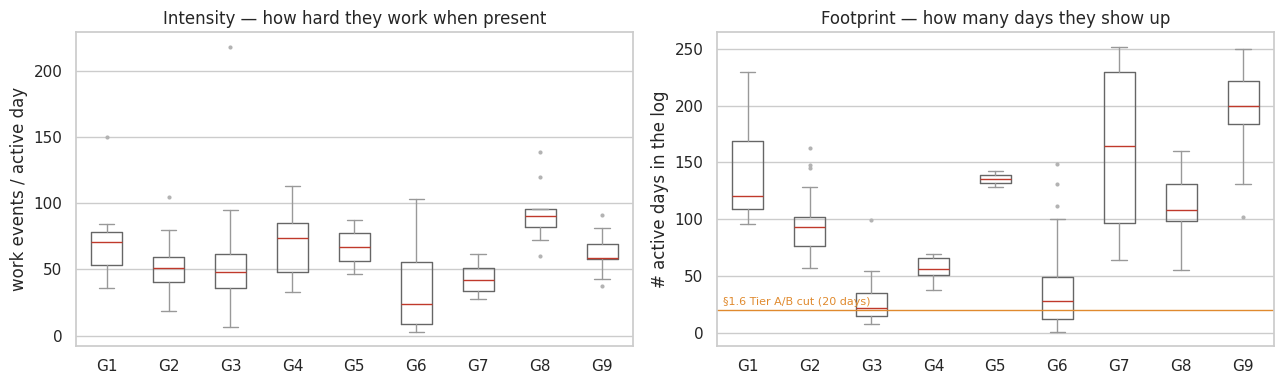

,n,med_active_days,med_span_days,med_evt_per_day
grp,,,,
0,1,NaN,NaN,NaN
1,18,120.5,364.0,70.8
2,27,93.0,336.0,51.1
3,34,21.5,79.5,48.1
4,8,56.5,159.5,73.7
5,2,135.0,309.0,66.8
6,28,27.5,175.0,24.1
7,4,164.5,294.0,41.7
8,13,108.0,295.0,90.1


In [ ]:
# "How much" (intensity) vs "how often" (footprint). G0 is the system account — it has no
# human presence to measure, so it is left out of both panels.
GH = [i for i in G if i != 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, ylab, title in [
    (axes[0], "evt_per_day", "work events / active day", "Intensity — how hard they work when present"),
    (axes[1], "active_days", "# active days in the log", "Footprint — how many days they show up"),
]:
    ax.boxplot([rf[rf["grp"] == i][col].dropna().values for i in GH],
               tick_labels=[f"G{i}" for i in GH],
               medianprops=dict(color=RED), boxprops=dict(color="0.4"),
               whiskerprops=dict(color="0.6"), capprops=dict(color="0.6"),
               flierprops=dict(marker="o", markersize=3, markerfacecolor="0.7",
                               markeredgecolor="none"))
    ax.set(ylabel=ylab, title=title); ax.grid(axis="x", visible=False)
axes[1].axhline(20, color=AMBER, lw=1)
axes[1].text(0.6, 24, "§1.6 Tier A/B cut (20 days)", color=AMBER, fontsize=8)
plt.tight_layout(); plt.show()

rf.groupby("grp").agg(n=("res", "size"),
                      med_active_days=("active_days", "median"),
                      med_span_days=("span_days", "median"),
                      med_evt_per_day=("evt_per_day", "median")).round(1)

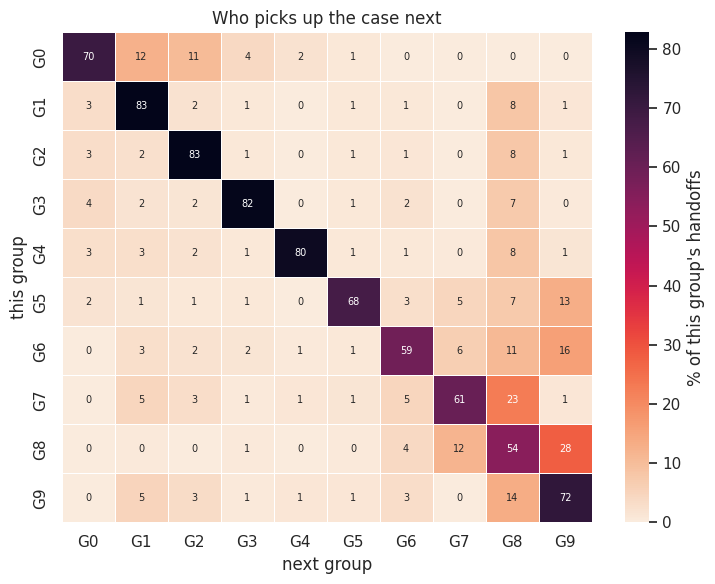

front-office work stays inside the front office: 86%
back-office work stays inside the back office  : 92%


In [ ]:
# Does work flow between the halves, or stay put? Look at who picks the case up next.
seq = work[["case:concept:name", "time:timestamp", "grp"]].sort_values(
    ["case:concept:name", "time:timestamp"], kind="mergesort")
seq["next_grp"] = seq.groupby("case:concept:name", observed=True)["grp"].shift(-1)
ho = pd.crosstab(seq["grp"], seq["next_grp"]).reindex(index=G, columns=G).fillna(0)
ho_pct = ho.div(ho.sum(axis=1).replace(0, np.nan), axis=0) * 100
del seq; gc.collect()

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(ho_pct, ax=ax, cmap="rocket_r", annot=True, fmt=".0f", annot_kws={"size": 7},
            linewidths=.4, linecolor="white", cbar_kws={"label": "% of this group's handoffs"},
            xticklabels=[f"G{i}" for i in G], yticklabels=[f"G{i}" for i in G])
ax.set(title="Who picks up the case next", xlabel="next group", ylabel="this group")
plt.tight_layout(); plt.show()

print(f"front-office work stays inside the front office: {ho_pct.loc[FRONT, FRONT].sum(axis=1).mean():.0f}%")
print(f"back-office work stays inside the back office  : {ho_pct.loc[BACK, BACK].sum(axis=1).mean():.0f}%")

### Verdict on the front-office pools: an artifact of **footprint**, not four teams

The two panels separate the candidates cleanly:

- **Intensity does not explain the split.** When they are at their desk, all four pools work at a comparable rate (medians ≈ 48–74 events/day). G3 — the "big" pool — is *not* a pool of slackers.
- **Footprint explains it exactly.** Median active days fall in a clean staircase: **G1 120 · G2 93 · G4 57 · G3 22**. G3's members are present a *fifth* as often as G1's, and their median span is only ~80 days out of a 398-day log — they are on the books for a couple of months, not a year.

That is the whole story. AHC clusters resources by *log-scaled counts of activity in each execution context*, and total volume = intensity × days present. With intensity roughly constant, the clustering had only one axis left to separate people on: **how many days they showed up**. G1–G4 are one front-office team, stratified by tenure and presence.

The handoff matrix confirms there is no functional split hiding behind it: work stays inside its own half of the bank (**86%** of front-office handoffs go to another front-office group, **92%** for the back office), and cases pass among G1–G4 interchangeably — the signature of one pool, not four teams with distinct remits.

> ⚠️ **This overturns a reading of the §9 table — worth stating plainly.** §9's signature column reported `W_Handle leads` at 47% for G1, which invites "G1 is the outreach team". Normalised within each group, lead-handling is **1.5% of G1's own work — and 2.0% of G4's**. G1 does not specialise in outreach; it merely does 47% of the bank's lead-handling *because it is the busiest pool*. A bank-wide share measures size; only the within-group share measures a role. The §9 table was not wrong, but one natural reading of it was, and this is the check that catches it.

143 of 144 group members carry a fitted §1.6 window (the one without is User_1 — modelled as an always-on system account)


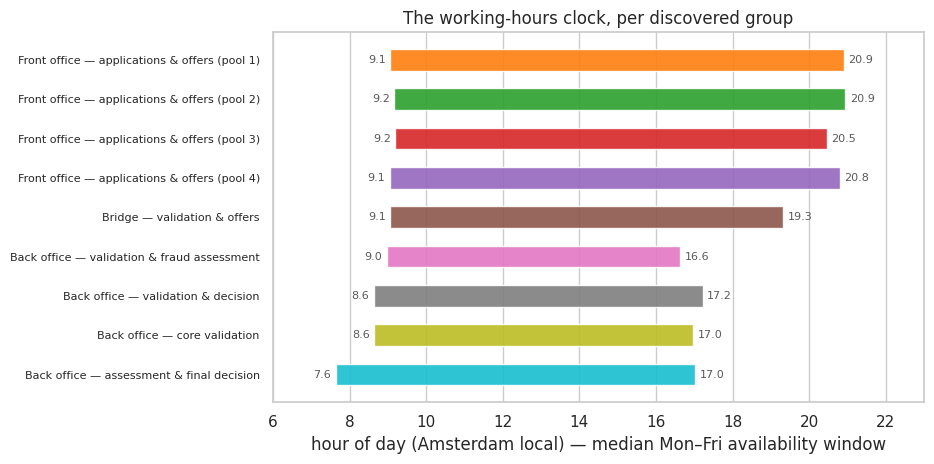

front office: opens  9.12   closes 20.78   envelope 11.66 h
back office: opens  8.47   closes 16.96   envelope 8.49 h


,open,close,span
grp,,,
1,9.07,20.91,11.84
2,9.17,20.94,11.77
3,9.20,20.46,11.26
4,9.05,20.80,11.75
5,9.06,19.33,10.26
6,8.97,16.63,7.66
7,8.63,17.22,8.58
8,8.64,16.97,8.33
9,7.64,17.03,9.39


In [ ]:
# Lens 2 — overlay the §1.6 windows. These were fitted with no knowledge of the groups.
wdf = pd.DataFrame([(res2grp[r], r, int(d), s, e) for r, wd in avail["windows"].items()
                    if r in res2grp for d, (s, e) in wd.items()],
                   columns=["grp", "res", "dow", "open", "close"])
print(f"{wdf['res'].nunique()} of {len(rf)} group members carry a fitted §1.6 window "
      f"(the one without is User_1 — modelled as an always-on system account)")

clock = wdf[wdf["dow"] < 5].groupby("grp").agg(open=("open", "median"),
                                               close=("close", "median"))
clock["span"] = clock["close"] - clock["open"]

fig, ax = plt.subplots(figsize=(9.5, 4.8))
for y, i in enumerate(clock.index):
    o, c = clock.loc[i, "open"], clock.loc[i, "close"]
    ax.barh(y, c - o, left=o, height=.55, color=plt.get_cmap("tab10")(i % 10), alpha=.9)
    ax.text(o - .12, y, f"{o:.1f}", ha="right", va="center", fontsize=8, color="0.35")
    ax.text(c + .12, y, f"{c:.1f}", ha="left", va="center", fontsize=8, color="0.35")
ax.set_yticks(range(len(clock))); ax.set_yticklabels([ROLES[i] for i in clock.index], fontsize=8)
ax.set(xlim=(6, 23), xlabel="hour of day (Amsterdam local) — median Mon–Fri availability window",
       title="The working-hours clock, per discovered group")
ax.invert_yaxis(); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

for name, ids in [("front office", FRONT), ("back office", BACK)]:
    sel = clock.loc[[i for i in ids if i in clock.index]]
    print(f"{name}: opens {sel['open'].mean():5.2f}   closes {sel['close'].mean():5.2f}   "
          f"envelope {sel['span'].mean():4.2f} h")
clock.round(2)

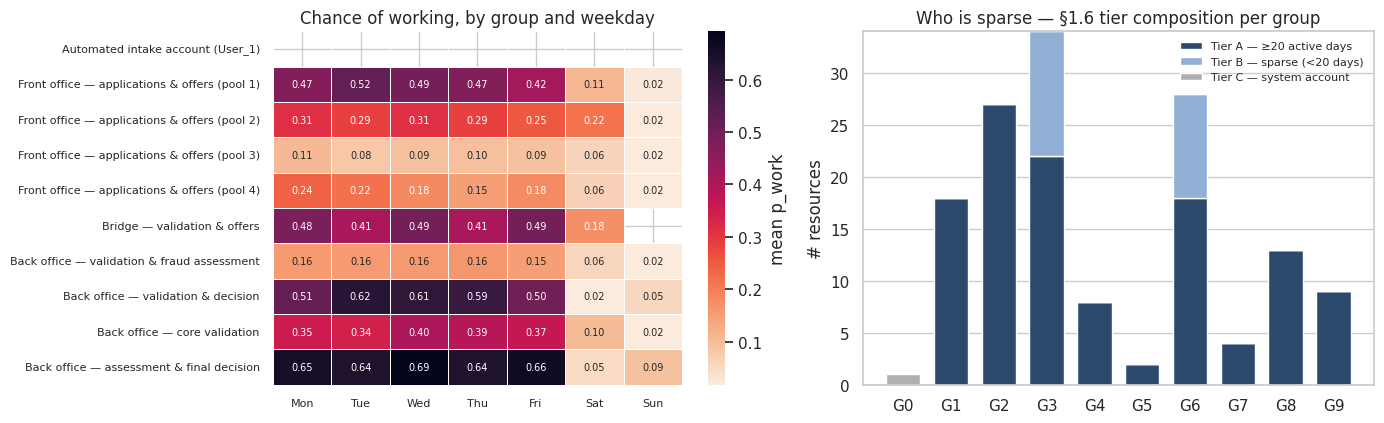

Tier B (sparse) share:  front office 14%   back office 19%
every Tier B resource sits in: [3, 6]


tier,A,B,C
grp,,,
0,0,0,1
1,18,0,0
2,27,0,0
3,22,12,0
4,8,0,0
5,2,0,0
6,18,10,0
7,4,0,0
8,13,0,0


In [ ]:
pdf = pd.DataFrame([(res2grp[r], int(d), p) for r, wd in avail["p_work"].items()
                    if r in res2grp for d, p in wd.items()], columns=["grp", "dow", "p"])
pw = pdf.groupby(["grp", "dow"])["p"].mean().unstack("dow").reindex(G)
pw.columns = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"][:pw.shape[1]]

tc = rf.groupby(["grp", "tier"]).size().unstack("tier").reindex(G).fillna(0)
for t in ["A", "B", "C"]:
    if t not in tc.columns:
        tc[t] = 0.0
tc = tc[["A", "B", "C"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
sns.heatmap(pw, ax=axes[0], cmap="rocket_r", annot=True, fmt=".2f", annot_kws={"size": 7},
            linewidths=.4, linecolor="white", cbar_kws={"label": "mean p_work"},
            yticklabels=[ROLES[i] for i in G])
axes[0].set(title="Chance of working, by group and weekday", xlabel="", ylabel="")
axes[0].tick_params(labelsize=8)

bottom = np.zeros(len(tc))
for t, colour, lab in [("A", "#2c4a6e", "Tier A — ≥20 active days"),
                       ("B", "#8fb0d4", "Tier B — sparse (<20 days)"),
                       ("C", "#b0b0b0", "Tier C — system account")]:
    axes[1].bar([f"G{i}" for i in tc.index], tc[t].values, bottom=bottom,
                label=lab, color=colour, width=.72)
    bottom += tc[t].values
axes[1].set(ylabel="# resources", title="Who is sparse — §1.6 tier composition per group")
axes[1].legend(frameon=False, fontsize=8); axes[1].grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

print("Tier B (sparse) share:  "
      f"front office {rf[rf['grp'].isin(FRONT)]['tier'].eq('B').mean():.0%}   "
      f"back office {rf[rf['grp'].isin(BACK)]['tier'].eq('B').mean():.0%}")
print("every Tier B resource sits in:",
      sorted(rf[rf["tier"] == "B"]["grp"].unique().tolist()))
tc.astype(int)

### Verdict on the clock: the two halves of the bank keep **different hours**

This is the result worth having, because the two models never met. The org groups were discovered from *what* people do; the windows were fitted from *when* they are present. Nothing in either pipeline knows about the other — yet the clock splits along exactly the same seam:

| | opens | closes | envelope |
|---|---|---|---|
| **Front office** (G1–G4) | ~09:07 | ~20:47 | **11.7 h** |
| **Back office** (G6–G9) | ~08:28 | ~16:58 | **8.5 h** |

The back office is a **standard office operation** — in by half eight, out by five. The front office is **open into the evening**, closing nearly **four hours later**. And the bridge group (G5) — the two people whose work mixes both halves — sits between the two on the clock as well (09:04 → 19:20). The weekday heatmap adds the same story: the front office turns up on Saturdays (`p_work` up to 0.22 in G2), while the back office essentially never does (0.02–0.10).

That is a customer-facing channel versus an administrative one, recovered twice from two independent signals. It is the strongest corroboration in this notebook that the discovered groups are real organizational units and not clustering noise.

**A caveat on what the envelope means.** A §1.6 window is `[q10 of first event, q90 of last event]` across a resource's active days — an *outer envelope*, not a shift. An 11.7-hour front-office envelope does **not** mean anyone works 11.7-hour days; combined with `p_work ≈ 0.5`, it much more plausibly describes **shift coverage**: different people covering a 09:00–21:00 service window on different days. Fitting one envelope per resource cannot represent that, and averages a morning and an evening shift worker into one implausible all-day person. Recognising shifts within the front office is the natural next step for §1.6 — see the decisions below.

### The two lenses meet: who the sparse resources are

The tier panel closes the loop with §1.6. **Every one of the 22 Tier B (sparse) resources sits in exactly two groups — G3 and G6** (12 and 10 respectively); every other group is pure Tier A. That is an independent rediscovery of the §1.6 finding that the sparse resources are not scattered noise, and it sharpens it: the sparse front-office people (G3) are *the same job* as the full-timers beside them (work-mix distance 6.0), just present a fifth as often — precisely the part-timer / mid-year joiner / long-term-absent population §1.6 hypothesised. They are an addition to the front-office team, not a team of their own.

> **Decision 8.** Report G1–G4 as **one front-office team stratified by presence**, not four sub-teams. The four-way split is an artifact of AHC clustering on volume-scaled features when the underlying work mix is identical (distance 6.0 within, 93 across the front/back seam). We keep the deployed model as-is — the permissions it grants are still right, since all four pools inherit the same front-office capabilities — but we do not claim four roles where there is one.
>
> **Decision 9.** Treat the front/back clock difference as **corroboration, not coincidence**: two independent models agreeing on one seam. The §1.6 model already captures it (windows are per resource, so front-office staff carry their own later hours) — but the 11.7 h front-office envelope flags shift structure that a single per-resource window cannot express. Recorded as future work for §1.6, alongside the Tier B window assumption.

---
## 11. Exploration — would **loan size** have been the better case-type dimension?

*Exploratory. Nothing in this section is deployed; the simulation keeps `CT+AT+TT(ca)` with case types from `case:LoanGoal`.*

§9 noted in passing that the case-type dimension is "near-full for almost every group" — every group works on essentially every loan goal, so what separates the groups is the **activity**, not the customer. That invites an obvious challenge: maybe we simply picked the *wrong* case attribute. A bank plausibly routes a EUR 300,000 application differently from a EUR 5,000 one — to a senior desk, a four-eyes check, a different team. If so, `case:RequestedAmount` would be a better case-type dimension than `case:LoanGoal`, and the deployed model is built on the weaker of the two.

**Hypothesis.** Large applications route to a distinct, perhaps more senior group. If true, at least one discovered group should skew towards large amounts, and building execution contexts from the amount should discover a materially different org chart.

The test runs in four steps, cheapest first:

1. **Does the amount separate the groups we already have?** No re-mining needed — just ask what each of the ten deployed groups works on.
2. **A new case-type variant** — `CT+AT+TT(amt)`, amount in quartiles.
3. **Score it** the same way as everything else (AHC + complete linkage + OverallScore).
4. **The question that actually matters** — does the *org chart* change, or is it the same partition re-scored?

Step 4 is the point. Conformance can improve for reasons that have nothing to do with the organization.

**What the amounts look like.** Heavily right-skewed: median **EUR 12,500**, q75 21,000, q90 35,000, q99 73,000, max 450,000 — and only **20 of 31,509 cases** exceed EUR 100k. So the bins have to be **quantiles**. A round-number "large loan = above EUR 100k" cut would put 0.06% of cases on one side and everything else on the other, and would test nothing.

In [ ]:
# §11 Step 1 — the cheap decisive test: does the amount separate the ten deployed groups?
#
# Same total-variation test used throughout §9-§10, but measured against the BANK-WIDE
# distribution rather than between groups: for each group, how far is its distribution
# over a case dimension from the bank's? 0 = this group sees the same mix as everyone
# else; 1 = it works on a disjoint slice of the business. Run over four dimensions so
# the amount is read against a scale, not in isolation.
amt_case = el.groupby("case:concept:name")["case:RequestedAmount"].first()

# Quantile bins (deciles), not fixed thresholds — see the note above. Deciles rather
# than quartiles so the amount gets a category count comparable to loan goal's 14;
# coarser bins can only *lower* a TV distance, so this is the generous setting.
edges = np.unique(amt_case.quantile(np.linspace(0, 1, 11)).values).astype(float).copy()
edges[0], edges[-1] = -np.inf, np.inf

w = work.assign(
    amt_bin=pd.cut(work["case:RequestedAmount"], bins=edges, labels=False,
                   include_lowest=True),
    weekday_name=work["time:timestamp"].dt.day_name(),
)

def tv_from_bankwide(col):
    """Per group: TV distance between its distribution over `col` and the bank-wide one."""
    p = pd.crosstab(w["grp"], w[col]).pipe(lambda t: t.div(t.sum(axis=1), axis=0))
    bank = w[col].value_counts(normalize=True).reindex(p.columns).fillna(0)
    return 0.5 * (p - bank).abs().sum(axis=1)

DIMS = {"activity": "concept:name", "weekday": "weekday_name",
        "loan goal": "case:LoanGoal", "requested amount": "amt_bin"}
tvs = pd.DataFrame({k: tv_from_bankwide(v) for k, v in DIMS.items()})

print("Mean TV distance of a group's case mix from the bank-wide mix")
print("  (0 = this group sees what everyone sees, 1 = it works on its own slice)\n")
for k in DIMS:
    print(f"  {k:18s} mean {tvs[k].mean():.3f}   max {tvs[k].max():.3f}   "
          f"({w[DIMS[k]].nunique()} categories)")

profile = pd.DataFrame({
    "Role (our reading)": pd.Series(ROLES),
    "#res": [len(g["members"]) for g in om["groups"]],
    "median amt": w.groupby("grp")["case:concept:name"].apply(
        lambda c: amt_case.reindex(c.unique()).median()),
    "q90 amt": w.groupby("grp")["case:concept:name"].apply(
        lambda c: amt_case.reindex(c.unique()).quantile(.9)),
    "TV amount": tvs["requested amount"].round(3),
    "TV loan goal": tvs["loan goal"].round(3),
    "TV activity": tvs["activity"].round(3),
})
print(f"\nbank-wide: median EUR {amt_case.median():,.0f}   q90 EUR {amt_case.quantile(.9):,.0f}")
profile

Mean TV distance of a group's case mix from the bank-wide mix
  (0 = this group sees what everyone sees, 1 = it works on its own slice)

  activity           mean 0.539   max 0.756   (24 categories)
  weekday            mean 0.098   max 0.171   (7 categories)
  loan goal          mean 0.056   max 0.118   (14 categories)
  requested amount   mean 0.056   max 0.165   (9 categories)

bank-wide: median EUR 12,500   q90 EUR 35,000


,Role (our reading),#res,median amt,q90 amt,TV amount,TV loan goal,TV activity
0,Automated intake account (User_1),1,12500.0,34000.0,0.053,0.072,0.756
1,Front office — applications & offers (pool 1),18,13000.0,35000.0,0.017,0.010,0.386
2,Front office — applications & offers (pool 2),27,13500.0,35000.0,0.006,0.014,0.392
3,Front office — applications & offers (pool 3),34,14000.0,34320.0,0.023,0.041,0.433
4,Front office — applications & offers (pool 4),8,10000.0,33000.0,0.106,0.118,0.369
5,Bridge — validation & offers,2,15000.0,35000.0,0.037,0.065,0.277
6,Back office — validation & fraud assessment,28,13300.0,30000.0,0.040,0.034,0.602
7,Back office — validation & decision,4,10000.0,21500.0,0.165,0.083,0.749
8,Back office — core validation,13,14000.0,35000.0,0.012,0.020,0.691
9,Back office — assessment & final decision,9,15000.0,40000.0,0.102,0.098,0.733


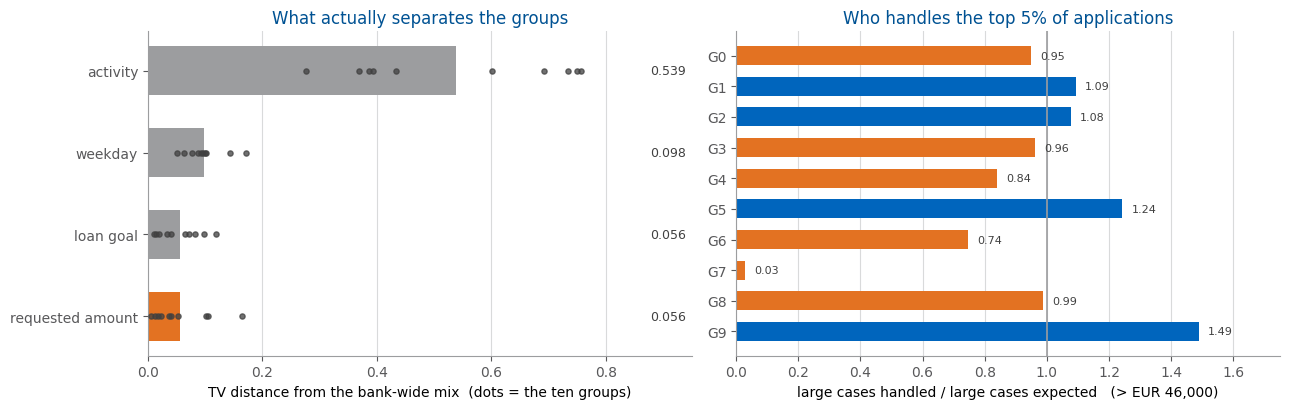

,#cases touched,top-5% observed,top-5% expected,obs/exp
group,,,,
0,22473,1060,1115.5,0.950
1,17650,958,876.1,1.093
2,15271,816,758.0,1.077
3,5897,282,292.7,0.963
4,3289,137,163.3,0.839
5,3500,216,173.7,1.243
6,6243,231,309.9,0.745
7,6616,10,328.4,0.030
8,19691,965,977.4,0.987


In [ ]:
# §11 Step 1b — the large loans specifically. If a senior desk exists, the top-5% of
# cases by amount (> EUR 46k) must land somewhere in particular. Counted per CASE and
# against the count expected if large cases were routed like any other.
cut = amt_case.quantile(0.95)
top = set(amt_case[amt_case > cut].index)

rows = []
for i in G:
    cases = set(w[w["grp"] == i]["case:concept:name"])
    obs = len(cases & top)
    exp = len(cases) * len(top) / len(amt_case)
    rows.append({"group": i, "#cases touched": len(cases), "top-5% observed": obs,
                 "top-5% expected": round(exp, 1), "obs/exp": round(obs / exp, 3)})
routing = pd.DataFrame(rows).set_index("group")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

ax = axes[0]
order = list(DIMS)
means = [tvs[k].mean() for k in order]
cols = [TUM_GRAY if k != "requested amount" else AMBER for k in order]
ax.barh(order, means, color=cols, height=.6, zorder=2)
for k, m in zip(order, means):                       # per-group spread over the mean
    ax.scatter(tvs[k], [k] * len(tvs), s=14, color="0.25", alpha=.75, zorder=3)
    # values in a column at the right edge, so they never collide with the dots
    ax.text(0.94, k, f"{m:.3f}", va="center", ha="right", fontsize=9, color="0.25")
ax.set(xlabel="TV distance from the bank-wide mix  (dots = the ten groups)",
       title="What actually separates the groups", xlim=(0, 0.95))
ax.grid(axis="y", visible=False); ax.invert_yaxis()

ax = axes[1]
r = routing["obs/exp"]
ax.barh([f"G{i}" for i in r.index], r.values, height=.62, zorder=2,
        color=[BLUE if v >= 1 else AMBER for v in r.values])
ax.axvline(1.0, color=TUM_GRAY, lw=1.2, zorder=3)
for i, v in zip(r.index, r.values):
    ax.text(v + .03, f"G{i}", f"{v:.2f}", va="center", fontsize=8, color="0.25")
ax.set(xlabel=f"large cases handled / large cases expected   (> EUR {cut:,.0f})",
       title="Who handles the top 5% of applications", xlim=(0, 1.75))
ax.grid(axis="y", visible=False); ax.invert_yaxis()
plt.tight_layout(); plt.show()

routing

**The hypothesis is dead at step 1.** A group's case mix departs from the bank-wide mix by a mean TV distance of **0.539 on activity** — and **0.056 on the requested amount**, which is *identical* to loan goal's 0.056 and smaller than weekday's 0.098. The amount is the **weakest** of the four dimensions tested. Every group's median requested amount sits between EUR 10,000 and 15,000 against a bank-wide median of 12,500, and every group's q90 sits at 30,000–40,000 against a bank-wide 35,000. There is no senior large-loan desk; there are ten groups all seeing the same customers and doing different *work*.

Steps 2–4 are therefore confirmatory. We run them anyway, because "the attribute carries no signal" and "the attribute carries no signal *that survives being turned into execution contexts*" are different claims, and only the second one closes the question.

⚠️ **One real exception, and it runs the other way.** **G7** — four people, `User_90/100/102/115` — touched 6,616 cases of which **10 were in the top 5% by amount, against 328 expected**: a **33x under-representation**, and by far the largest amount signal anywhere in the model (TV 0.165, median EUR 10,000 vs 12,500 bank-wide). It is not explained by application type (the ratio is 0.023 within *both* `New credit` and `Limit raise`), by case length (median 15 events vs the bank's 14; Spearman correlation between case length and amount is 0.065), by tenure (its members are full-year Tier A staff), or by a hard ceiling (they do occasionally touch cases up to EUR 260,000). So the one place where loan size visibly shapes who works on a case is a small desk that almost never sees **large** applications — the mirror image of the hypothesis, at 3% of the bank's events. Noted as a lead, not a finding; it is already visible in the deployed model and needs no new case types to see. **§12 puts a null under this**: G7's tilt clears it at z = −4.0, but so does G9's in the *opposite* direction (1.46x, z = +3.0), so the tail effect is real, two-directional, and still not a senior large-loan desk.

In [ ]:
# §11 Steps 2 & 3 — build the amount-based case types and score them exactly like the rest.
#
# `CT+AT+TT(amt)`    : case types = quartiles of case:RequestedAmount ("AMT.Q1".."AMT.Q4")
# `CT+AT+TT(ca*amt)` : case types = loan goal x amount quartile, to see whether the two
#                      attributes are additive or whether the amount just fragments contexts
#
# `CT+AT+TT(ca)` is re-run as a CONTROL. It should reproduce the deployed model exactly —
# which makes it the calibration for the adjusted Rand index in step 4: without it, we
# would not know whether an ARI below 1.0 means "different org chart" or "noisy pipeline".
import time
from analysis.permissions import amount_quartiles

q = amount_quartiles(el)
print("amount quartiles (cases per bin):",
      el.assign(q=q).groupby("case:concept:name")["q"].first().value_counts().sort_index().to_dict())
print(f"edges: EUR {amt_case.quantile(.25):,.0f} / {amt_case.median():,.0f} / "
      f"{amt_case.quantile(.75):,.0f}\n")

variants, models = ["CT+AT+TT(ca)", "CT+AT+TT(amt)", "CT+AT+TT(ca*amt)"], {}
for ctx in variants:
    t0 = time.time()
    _, rl_v = P.build_resource_log(el, ctx)
    models[ctx] = P.discover(rl_v, n_groups=10, discovery="AHC",
                             profiling="OverallScore", contexts=ctx)
    print(f"  {ctx:18s} {models[ctx].n_contexts:5d} contexts   "
          f"F1 = {models[ctx].f1:.3f}   ({time.time() - t0:.0f}s)", flush=True)

scores = pd.DataFrame([models[c].as_row() for c in variants])
scores["note"] = ["deployed (case types from the loan goal)",
                  "NEW — case types from the amount",
                  "NEW — loan goal x amount quartile"]
scores.set_index("contexts")[["#contexts", "#groups", "fitness", "precision", "F1", "note"]]

amount quartiles (cases per bin): {'AMT.Q1': 8482, 'AMT.Q2': 7322, 'AMT.Q3': 7838, 'AMT.Q4': 7867}
edges: EUR 6,000 / 12,500 / 21,000



  CT+AT+TT(ca)        1960 contexts   F1 = 0.719   (140s)


  CT+AT+TT(amt)        651 contexts   F1 = 0.726   (136s)


  CT+AT+TT(ca*amt)    6831 contexts   F1 = 0.707   (150s)


,#contexts,#groups,fitness,precision,F1,note
contexts,,,,,,
CT+AT+TT(ca),1960,10,0.922,0.590,0.719,deployed (case types from the loan goal)
CT+AT+TT(amt),651,10,0.929,0.595,0.726,NEW — case types from the amount
CT+AT+TT(ca*amt),6831,10,0.819,0.622,0.707,NEW — loan goal x amount quartile


Groups discovered from AMOUNT-based contexts — what separates *them*?


  activity           mean TV 0.514   (deployed groups: 0.539)
  weekday            mean TV 0.139   (deployed groups: 0.098)
  loan goal          mean TV 0.066   (deployed groups: 0.056)


  requested amount   mean TV 0.064   (deployed groups: 0.056)


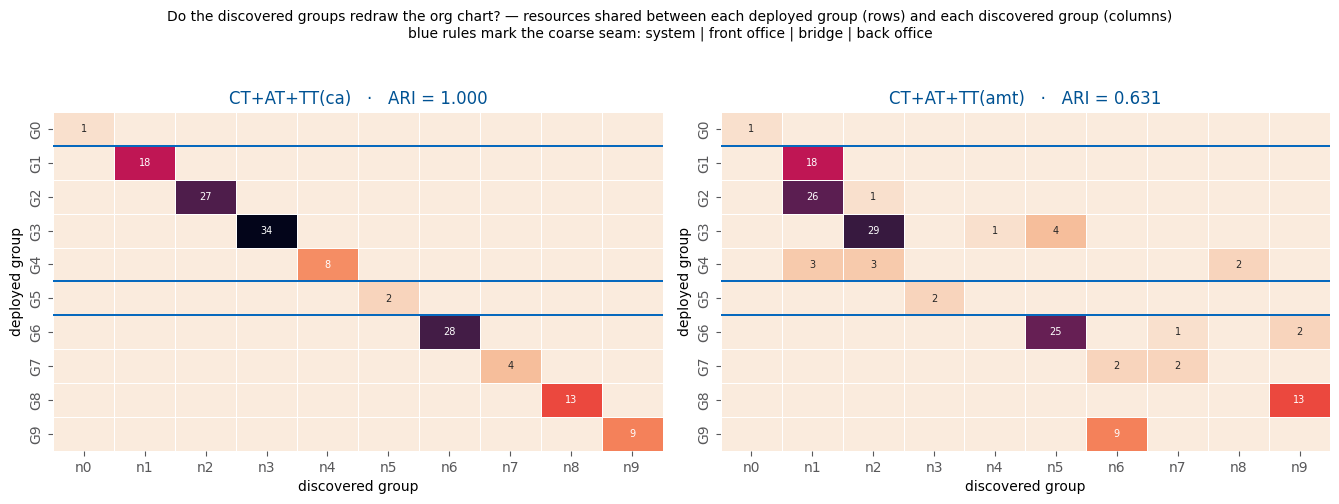

,F1,ARI vs deployed,ARI · back office,ARI · front office,keeps front/back identity
contexts,,,,,
CT+AT+TT(ca),0.719,1.000,1.000,1.000,144/144
CT+AT+TT(amt),0.726,0.631,0.801,0.482,140/144
CT+AT+TT(ca*amt),0.707,0.441,0.671,0.520,124/144


In [ ]:
# §11 Step 4 — the question that actually matters. Conformance is not the point:
# does the ORG CHART change? Compare each discovered partition of the 144 resources
# against the deployed ten groups.
from sklearn.metrics import adjusted_rand_score

def partition(m):
    return {r: gid for gid, members in m.om.find_all_groups() for r in members}

COARSE = {0: "system", 1: "front", 2: "front", 3: "front", 4: "front",
          5: "bridge", 6: "back", 7: "back", 8: "back", 9: "back"}

cmp_rows, overlaps, aris = [], {}, {}
for ctx in variants:
    p = partition(models[ctx])
    res = sorted(set(p) & set(res2grp))
    a = pd.Series([res2grp[r] for r in res], index=res, name="deployed")
    b = pd.Series([p[r] for r in res], index=res, name=ctx)
    overlaps[ctx] = pd.crosstab(a, b)
    aris[ctx] = adjusted_rand_score(a, b)

    # Does a resource keep its front/back/bridge/system identity? Label each new group
    # by the coarse half it mostly holds, then ask how many resources stay put.
    coarse = a.map(COARSE)
    maj = pd.crosstab(coarse, b).idxmax()
    kept = (coarse == b.map(maj)).sum()

    cmp_rows.append({
        "contexts": ctx, "F1": round(models[ctx].f1, 3),
        "ARI vs deployed": round(aris[ctx], 3),
        "ARI · back office": round(adjusted_rand_score(
            a[coarse == "back"], b[coarse == "back"]), 3),
        "ARI · front office": round(adjusted_rand_score(
            a[coarse == "front"], b[coarse == "front"]), 3),
        "keeps front/back identity": f"{kept}/{len(res)}",
    })

# And the confirmatory test: even with contexts built FROM the amount, do the groups
# it discovers separate by amount? Re-run step 1's measure on the new partition.
amt_p = partition(models["CT+AT+TT(amt)"])
wa = w.assign(newgrp=w["org:resource"].map(amt_p))

def tv_new(col):
    p = pd.crosstab(wa["newgrp"], wa[col]).pipe(lambda t: t.div(t.sum(axis=1), axis=0))
    bank = wa[col].value_counts(normalize=True).reindex(p.columns).fillna(0)
    return 0.5 * (p - bank).abs().sum(axis=1)

print("Groups discovered from AMOUNT-based contexts — what separates *them*?")
for k, c in DIMS.items():
    print(f"  {k:18s} mean TV {tv_new(c).mean():.3f}   "
          f"(deployed groups: {tvs[k].mean():.3f})")

vmax = max(o.values.max() for o in overlaps.values())
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
for ax, ctx in zip(axes, ["CT+AT+TT(ca)", "CT+AT+TT(amt)"]):
    o = overlaps[ctx]
    sns.heatmap(o, ax=ax, cmap="rocket_r", vmin=0, vmax=vmax,   # one scale for both
                annot=o.replace(0, "").astype(str), fmt="",     # hide the zeros
                annot_kws={"size": 7}, linewidths=.4, linecolor="white", cbar=False,
                xticklabels=[f"n{c}" for c in o.columns],
                yticklabels=[f"G{i}" for i in o.index])
    for y in (1, 5, 6):        # the coarse seam: system | front office | bridge | back office
        ax.axhline(y, color=TUM_BLUE, lw=1.4)
    ax.set(title=f"{ctx}   ·   ARI = {aris[ctx]:.3f}",
           xlabel="discovered group", ylabel="deployed group")
fig.suptitle("Do the discovered groups redraw the org chart? — resources shared between each "
             "deployed group (rows) and each discovered group (columns)\n"
             "blue rules mark the coarse seam: system | front office | bridge | back office",
             y=1.04, fontsize=10)
plt.tight_layout(); plt.show()

pd.DataFrame(cmp_rows).set_index("contexts")

### Verdict: **the amount does not define this organization — and it does not redraw it either**

**Step 3 — conformance says almost nothing.** `CT+AT+TT(amt)` scores **fitness 0.929 / precision 0.595 / F1 0.726**, against the deployed `CT+AT+TT(ca)` at **0.922 / 0.590 / 0.719**. That is **+0.007 F1** — and it is not evidence for the hypothesis. The amount variant defines only **651 execution contexts** where the loan goal defines 1,960 (4 case types instead of 14), and *fewer, larger contexts are simply easier to fit*: more events per context means more evidence per group capability, so both fitness and precision drift up. The composite `CT+AT+TT(ca*amt)` settles it — 6,831 contexts, and F1 falls to **0.707** (fitness 0.819, precision 0.622). The two attributes are **not additive**; multiplying them fragments the log until each context is too thin to support a capability. If the amount carried independent signal about who does the work, the composite is where it would show, and it is where the score gets worse.

**Step 4 — the org chart is the same org chart.** The control re-run of `CT+AT+TT(ca)` reproduces the deployed model exactly (**ARI = 1.000**, a clean diagonal), so the pipeline is deterministic and any departure from 1.0 is real. `CT+AT+TT(amt)` comes back at **ARI = 0.631** — but reading *where* the disagreement sits dissolves it:

- **140 of 144 resources keep their front-office / back-office / bridge / system identity.** The seam that §9–§10 established as the real structure of the bank is untouched.
- **The disagreement is concentrated exactly where §10 already showed the boundaries are arbitrary**: ARI is **0.801** inside the back office, where the groups are genuine specialisations (fraud, core validation, final decision), and **0.482** inside the front office, whose four pools §10 showed are *one team split by footprint*, not four teams. Re-running with different contexts reshuffles pools that were never real to begin with. Deployed G1 and G2 (18 + 27 people) simply merge into one 47-person pool; G8 and G9 survive intact, 13-for-13 and 9-for-9.
- **The four resources that do cross the seam are the sparse ones** — all four from G3, three of them Tier B (<20 active days). They join G6, and §10 already reported that G3 and G6 are precisely where all 22 sparse resources live. Low-volume resources cluster with low-volume resources; that is the log-scaled-count artifact §10 named, showing up again.

The composite makes the same point louder: `CT+AT+TT(ca*amt)` scrambles the partition hardest (**ARI 0.441**, only **124/144** resources keeping their half of the bank) while scoring **worst**. That is the signature of fragmentation, not of structure — thin contexts make group capabilities unstable, and an unstable clustering disagrees with everything, including the truth.

**The confirmatory result is the sharpest one.** Even when the execution contexts are built **from the amount quartiles themselves**, the groups that come out are *still* separated by activity (mean TV **0.514**) and *still* not by amount (mean TV **0.064**, against loan goal's 0.066 on the same partition). You can hand OrdinoR the loan size as the only case dimension it has, and it will hand you back the front office and the back office.

> **Decision 10 (exploratory, not deployed).** Keep `case:LoanGoal` as the case-type dimension. `case:RequestedAmount` separates the discovered groups no better than the loan goal does (mean TV 0.056 vs 0.056, against 0.539 for activity), buys +0.007 F1 through coarser contexts rather than better structure, is *anti*-additive with the loan goal (F1 0.707 for the composite), and leaves the org chart intact where that chart is real (140/144 resources keep their half of the bank; ARI 0.801 in the back office). **This is a negative result, and it is the useful kind:** it independently confirms §9–§10's central claim that this organization is defined by **what people do, not by which customers they serve.**

**For the report — future work, ready to lift.**

> We tested whether the requested loan amount would be a better case-type dimension than the loan goal, on the hypothesis that large applications route to a more senior group. It does not: across the ten discovered groups, the mean total-variation distance between a group's case mix and the bank-wide mix is 0.056 for the requested amount — identical to the loan goal's 0.056, and far below the 0.539 measured on the activity dimension. Case types built from amount quartiles score marginally higher (F1 0.726 vs 0.719) purely because 4 case types yield 651 execution contexts against the loan goal's 1,960, and the two attributes are anti-additive (the loan goal × amount composite falls to F1 0.707); the resulting partition is not a new org chart but the same one, with 140 of 144 resources keeping their front-office/back-office identity (ARI 0.801 within the back office, where the roles are real) and the disagreement confined to the front-office pools that §10 showed are one team stratified by presence. The largest amount-linked effect runs opposite to the hypothesis: group G7 (4 resources) touched 10 of an expected 328 top-5%-by-amount cases, a 33× under-representation not explained by application type, case length, or tenure — a small-application desk rather than a large-loan one. (§12 re-tests all of this against a permutation null and confirms it, while showing the effect runs in both directions: G9 sees large applications at 1.46× its expected share.)

*Reproduce this section:* `analysis/permissions.py` gains `amount_quartiles()` and two exploratory `build_resource_log()` variants, `"CT+AT+TT(amt)"` and `"CT+AT+TT(ca*amt)"`. Neither is in `scripts/sweep_org_models.py` and neither is deployed — `models/permissions_orgmodel.json` and the simulation are untouched.

---
## 12. What *determines* group membership? — the same questions, against a null

§9 through §11 leaned on one descriptive number: the mean total-variation distance between a group's distribution over some variable and the bank-wide distribution. Activity 0.54, weekday 0.10, loan goal 0.06, requested amount 0.06. Those numbers drove real conclusions, and they have a real flaw:

> **TV distance has no null.** It is sensitive to group size and event volume — a small group diverges from the bank-wide mix *by chance alone*, and a large one cannot. So "0.06 is small" and "0.54 is large" have been **assertions**, not tests. G5 has two resources and G0 has one; some of what we have been reading as structure could be arithmetic.

This section fixes that. Every effect from here on is reported **against its own null**, and only then compared with the others.

**The null.** Permute the resource → group assignment 1,000 times (seed **42**, stated so this is reproducible). Each permutation holds fixed:

- the **number of resources in each group** (18, 27, 34, 8, 2, 28, 4, 13, 9), and
- **each resource's own event count**, which travels with the resource.

So a permuted model is a fake org chart with the same shape and the same people, built from the same workload — but with membership scrambled. A group's *total* event volume is then preserved in distribution rather than exactly, which is the honest version of "volumes preserved": we are asking whether the observed separation beats an arbitrary partition of these people into these group sizes.

**Who is in scope.** G0 — the automated `User_1` account — is **excluded from this entire section**, and it has to be: §1.6 Decision 4 classifies it as a system account rather than staff, it is a group of one (the least-powered group in the model), and it carries no fitted availability window at all, so H5's active-day count is *undefined* for it. Including it would silently fold 16% of the log into whichever bin an undefined footprint lands in. That leaves **143 resources in 9 groups, 399,356 events** — so the numbers here are not identical to §9–§11's, which included it. G5 still has only two resources, and is flagged **underpowered** wherever it appears rather than given a p-value it cannot support.

**Two statistics, both reported.**

- **mean per-group TV distance** from the pooled distribution — continuous with §9–§11, so the old numbers can be read against their null.
- **Cramér's V** between the variable and the group label at the **event level** — bounded in [0, 1] and normalised by table size, so variables with 24 categories and variables with 4 can be ranked on one scale.

We rank by **ΔV = V observed − V under the null**, which is Cramér's V with its size bias subtracted off. This matters more than it sounds: with 399,356 events, the smallest attainable empirical p (0.001 with 1,000 permutations) is reached by effects far too small to mean anything. **The z-score tells you an effect is not zero; only ΔV tells you whether it is worth a sentence.** So the verdict column has two parts — *does it clear its null* and *is it big enough to matter* — with the second read against Cohen's conventional thresholds rescaled for table size (small = 0.1/√df), applied identically to every hypothesis.

**The hypotheses, each stated so it can fail.**

| | Hypothesis | Variable |
|---|---|---|
| **H1a** | Seniority/amount, distributional — high-value applications concentrate in particular groups | `case:RequestedAmount`, decile-binned |
| **H1b** | Seniority/amount, tail — the top 5% of cases by amount (> EUR 46k) land disproportionately | share of top-5% events vs share of all events |
| **H2** | Customer — the loan goal and the application type separate the groups | `case:LoanGoal`, `case:ApplicationType` |
| **H3** | Work — the activity separates the groups (expected to win; it still needs its null) | `concept:name` |
| **H4** | Clock — the weekday separates the groups, **and hour-of-day separately** | weekday; hour of day (24 bins) |
| **H5** | Footprint, not function — membership tracks how many days a resource is active | active-day count, per resource |

H4 is split deliberately. The org model's time dimension is the **weekday** — hour-of-day is a signal it *cannot see*, and §10 found the front office running ~09:00–20:47 against the back office's ~08:28–16:58. If hour-of-day clears its null while weekday barely does, that is a finding about the deployed model's time dimension being too coarse.

**And the confound.** Activity, amount and time are not independent. If a group owns a process stage that happens to attract larger loans, an "amount effect" is an activity effect wearing a disguise. So anything that clears its null is re-tested **stratified by activity**, and reported as direct or mediated.

In [ ]:
# §12 — the permutation engine. Everything below is counts of events, aggregated from
# resources into groups, so a permutation is one small matrix multiply and the whole
# 1,000-fold null over eight variables runs in seconds.
SEED, N_PERM = 42, 1000

# The automated account is excluded from this whole section, and it has to be. It is
# G0, a group of one; §1.6 Decision 4 classifies it as a system account rather than
# staff; it has NO active-day count at all (it carries no fitted §1.6 window), so H5 is
# undefined for it; and as a group of one it is the least powered group in the model.
# Detected structurally, via the §1.6 classification, not by hardcoding "User_1".
SYSTEM = set(avail["system"])
resources = [r for r in sorted(res2grp) if r not in SYSTEM]
r_idx = {r: i for i, r in enumerate(resources)}
raw_labels = np.array([res2grp[r] for r in resources])
GROUPS = sorted(set(raw_labels))                 # the 9 human groups, original ids
g_idx = {g: i for i, g in enumerate(GROUPS)}
labels = np.array([g_idx[g] for g in raw_labels])
NG = len(GROUPS)

# Event-level variables. Each event inherits its case's attributes, its own clock, and
# (for H5) the footprint of the resource that performed it.
amt_case = el.groupby("case:concept:name")["case:RequestedAmount"].first()
edges = np.unique(amt_case.quantile(np.linspace(0, 1, 11)).values).astype(float).copy()
edges[0], edges[-1] = -np.inf, np.inf
active_days = rf.set_index("res")["active_days"]

work_h = work[work["org:resource"].isin(r_idx)].copy()
V = work_h.assign(
    amount=pd.cut(work_h["case:RequestedAmount"], bins=edges, labels=False,
                  include_lowest=True),
    weekday=work_h["time:timestamp"].dt.dayofweek,
    hour=work_h["time:timestamp"].dt.hour,
    footprint=pd.qcut(work_h["org:resource"].map(active_days), 10,
                      labels=False, duplicates="drop"),
)
VARS = {"activity (H3)": "concept:name", "hour of day (H4)": "hour",
        "weekday (H4)": "weekday", "loan goal (H2)": "case:LoanGoal",
        "application type (H2)": "case:ApplicationType", "amount decile (H1a)": "amount",
        "resource footprint (H5)": "footprint"}

def resource_counts(col, extra=None):
    """Counts per (resource, category), or (resource, activity, category) if stratifying."""
    keys = ["org:resource"] + ([extra] if extra else []) + [col]
    codes = [np.asarray(V["org:resource"].map(r_idx))] + [
        np.asarray(pd.Categorical(V[k]).codes) for k in keys[1:]]
    # A -1 code means a missing value, which numpy would silently fold into the LAST
    # bin. Nothing should be missing here; assert it rather than trust it.
    for k, c in zip(keys, codes):
        assert c.min() >= 0, f"{k}: {(c < 0).sum()} events with a missing value"
    out = np.zeros([len(resources)] + [V[k].nunique() for k in keys[1:]])
    np.add.at(out, tuple(codes), 1.0)
    return out

def tv_and_v(C):
    """C: (..., n_groups, n_cats) counts -> (mean per-group TV, Cramer's V), vectorised.

    Empty rows (a group with no events in this stratum) are dropped from the TV mean.
    Cramer's V uses the full table shape for k, identically for observed and permuted
    values — a constant, so it cannot bias the comparison the test is built on.
    """
    C = np.asarray(C, float)
    n = C.sum((-2, -1), keepdims=True)
    row, col = C.sum(-1, keepdims=True), C.sum(-2, keepdims=True)
    p = np.divide(C, row, out=np.zeros_like(C), where=row > 0)
    bank = np.divide(col, n, out=np.zeros_like(col), where=n > 0)
    live = (row[..., 0] > 0)
    tvg = 0.5 * np.abs(p - bank).sum(-1) * live
    tv = tvg.sum(-1) / np.maximum(live.sum(-1), 1)
    exp = row * col / np.maximum(n, 1)
    chi2 = np.where(exp > 0, (C - exp) ** 2 / np.maximum(exp, 1e-12), 0).sum((-2, -1))
    k = max(min(C.shape[-2], C.shape[-1]) - 1, 1)
    return tv, np.sqrt(chi2 / np.maximum(n[..., 0, 0], 1) / k)

def aggregate(R, lab):
    """Sum resource-level counts into group-level counts for one labelling."""
    onehot = np.zeros((NG, R.shape[0]))
    onehot[lab, np.arange(R.shape[0])] = 1.0
    return (onehot @ R.reshape(R.shape[0], -1)).reshape((NG,) + R.shape[1:])

def permutation_test(R, lab=labels, n_perm=N_PERM, seed=SEED, stratified=False):
    """Observed statistics and their null, permuting the resource -> group assignment."""
    def stat(C):
        if not stratified:
            return tv_and_v(C)
        # C: (G, A, K) -> statistics per activity, volume-weighted into one number
        Ca = np.moveaxis(C, 1, 0)                       # (A, G, K)
        tv, v = tv_and_v(Ca)
        wgt = Ca.sum((-2, -1)); wgt = wgt / wgt.sum()
        return float(wgt @ tv), float(wgt @ v)

    obs_tv, obs_v = stat(aggregate(R, lab))
    rng = np.random.default_rng(seed)
    null = np.array([stat(aggregate(R, rng.permutation(lab))) for _ in range(n_perm)])
    out = {}
    for name, o, nu in [("TV", float(obs_tv), null[:, 0]), ("V", float(obs_v), null[:, 1])]:
        sd = nu.std(ddof=1)
        out[name] = {"obs": o, "null_mean": nu.mean(), "null_sd": sd,
                     "z": (o - nu.mean()) / sd if sd > 0 else np.nan,
                     "p": (1 + (nu >= o).sum()) / (n_perm + 1),
                     "delta": o - nu.mean()}
    return out

print(f"{len(resources)} human resources ({len(SYSTEM)} system account excluded), "
      f"{len(V):,} events, {NG} groups")
print(f"group sizes {dict(zip(GROUPS, np.bincount(labels).tolist()))}")
print(f"seed = {SEED}, {N_PERM} permutations  ->  smallest attainable p = "
      f"{1 / (N_PERM + 1):.4f}")
print("\nsanity check — the null must be centred where chance puts it, not at zero:")
_t = permutation_test(resource_counts("concept:name"))
print(f"  activity: observed TV {_t['TV']['obs']:.3f}   "
      f"null {_t['TV']['null_mean']:.3f} +/- {_t['TV']['null_sd']:.3f}")
print(f"\n  A RANDOM {NG}-way split of these {len(resources)} people, with the same group")
print(f"  sizes, already scores TV {_t['TV']['null_mean']:.3f} on activity. That — not zero —")
print(f"  is the bar the descriptive 0.54 of §9-§11 has to clear.")

143 human resources (1 system account excluded), 399,356 events, 9 groups
group sizes {np.int64(1): 18, np.int64(2): 27, np.int64(3): 34, np.int64(4): 8, np.int64(5): 2, np.int64(6): 28, np.int64(7): 4, np.int64(8): 13, np.int64(9): 9}
seed = 42, 1000 permutations  ->  smallest attainable p = 0.0010

sanity check — the null must be centred where chance puts it, not at zero:


  activity: observed TV 0.474   null 0.192 +/- 0.030

  A RANDOM 9-way split of these 143 people, with the same group
  sizes, already scores TV 0.192 on activity. That — not zero —
  is the bar the descriptive 0.54 of §9-§11 has to clear.


Ranked by dV = Cramer's V observed - Cramer's V under the null (1000 permutations, seed 42)

               hypothesis  V obs  V null    dV  V small-effect bar      z     p                                           verdict
            activity (H3)  0.420   0.137 0.283               0.035 13.612 0.001                                 SUPPORTED — large
  resource footprint (H5)  0.496   0.316 0.180               0.035  7.139 0.001                                 SUPPORTED — large
         hour of day (H4)  0.134   0.060 0.074               0.035  7.380 0.001                                 SUPPORTED — small
             weekday (H4)  0.103   0.058 0.045               0.041  5.542 0.001                                 SUPPORTED — small
      amount decile (H1a)  0.050   0.025 0.025               0.035  6.718 0.001 NOT SUPPORTED — clears null, effect below 'small'
           loan goal (H2)  0.048   0.029 0.018               0.035  5.046 0.001 NOT SUPPORTED — clears null, effect below 'smal

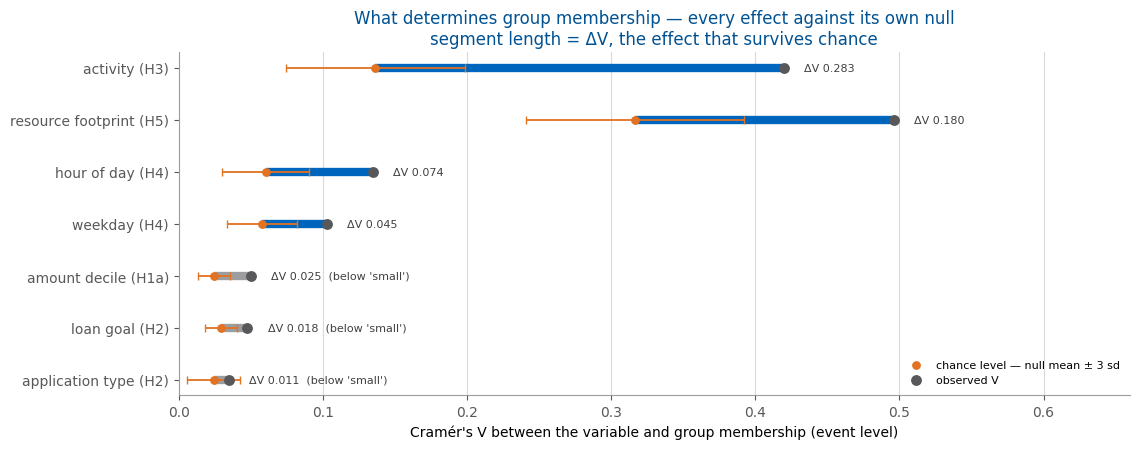

,hypothesis,categories,V obs,V null,null sd,dV,z,p,TV obs,TV null,verdict
0,activity (H3),23,0.4196,0.1365,0.0208,0.2831,13.6124,0.001,0.4740,0.1920,SUPPORTED — large
6,resource footprint (H5),10,0.4960,0.3165,0.0252,0.1796,7.1393,0.001,0.5922,0.4612,SUPPORTED — large
1,hour of day (H4),20,0.1345,0.0602,0.0101,0.0743,7.3796,0.001,0.1282,0.0719,SUPPORTED — small
2,weekday (H4),7,0.1028,0.0579,0.0081,0.0449,5.5416,0.001,0.0805,0.0667,SUPPORTED — small
5,amount decile (H1a),9,0.0498,0.0245,0.0038,0.0253,6.7178,0.001,0.0583,0.0365,"NOT SUPPORTED — clears null, effect below 'small'"
3,loan goal (H2),14,0.0476,0.0292,0.0037,0.0184,5.0459,0.001,0.0536,0.0355,"NOT SUPPORTED — clears null, effect below 'small'"
4,application type (H2),2,0.0348,0.0241,0.0061,0.0107,1.7619,0.044,0.0127,0.0090,NOT SUPPORTED — does not clear null
7,"amount tail, top 5% (H1b)",2,NaN,NaN,0.0109,NaN,3.6768,0.001,0.0793,0.0391,clears null (tail statistic)


In [ ]:
# §12 — every hypothesis against its own null, ranked by bias-corrected effect size.
rows = []
for name, col in VARS.items():
    t = permutation_test(resource_counts(col))
    rows.append({"hypothesis": name, "categories": V[col].nunique(),
                 "V obs": t["V"]["obs"], "V null": t["V"]["null_mean"],
                 "null sd": t["V"]["null_sd"], "dV": t["V"]["delta"],
                 "z": t["V"]["z"], "p": t["V"]["p"],
                 "TV obs": t["TV"]["obs"], "TV null": t["TV"]["null_mean"],
                 "TV z": t["TV"]["z"]})

# H1b — the tail test. Same null, different statistic: does a group's share of the
# top-5%-by-amount events depart from its share of all events?
cut = amt_case.quantile(0.95)
top = set(amt_case[amt_case > cut].index)
is_top = V["case:concept:name"].isin(top).to_numpy()
res_i = V["org:resource"].map(r_idx).to_numpy()
n_top = np.bincount(res_i[is_top], minlength=len(resources)).astype(float)
n_all = np.bincount(res_i, minlength=len(resources)).astype(float)

def tail_tv(lab):
    st = np.bincount(lab, weights=n_top, minlength=NG) / n_top.sum()
    sa = np.bincount(lab, weights=n_all, minlength=NG) / n_all.sum()
    return 0.5 * np.abs(st - sa).sum()

rng = np.random.default_rng(SEED)
tail_null = np.array([tail_tv(rng.permutation(labels)) for _ in range(N_PERM)])
tail_obs = tail_tv(labels)
rows.append({"hypothesis": "amount tail, top 5% (H1b)", "categories": 2,
             "V obs": np.nan, "V null": np.nan, "null sd": tail_null.std(ddof=1),
             "dV": np.nan, "z": (tail_obs - tail_null.mean()) / tail_null.std(ddof=1),
             "p": (1 + (tail_null >= tail_obs).sum()) / (N_PERM + 1),
             "TV obs": tail_obs, "TV null": tail_null.mean(), "TV z": np.nan})

rank = pd.DataFrame(rows).sort_values("dV", ascending=False, na_position="last")

# Verdict, in two parts, because at n = 475,306 events they come apart:
#   (1) does the effect clear its null at all?  (2) is it big enough to mean anything?
# Cohen's thresholds for w (0.1 small / 0.3 medium / 0.5 large) become thresholds on V
# after dividing by sqrt(df) — so a 24-category variable needs a smaller V than a
# 2-category one to say the same thing. Applied to dV, i.e. after the null is removed.
# This is a stated convention, not a law, but it is a *principled* one and it is applied
# identically to every hypothesis.
def verdict(r):
    if r["p"] >= 0.01:
        return "NOT SUPPORTED — does not clear null"
    if pd.isna(r["dV"]):
        return "clears null (tail statistic)"
    df = max(min(NG, r["categories"]) - 1, 1)
    small, medium, large = (t / np.sqrt(df) for t in (0.1, 0.3, 0.5))
    if r["dV"] >= large:   return "SUPPORTED — large"
    if r["dV"] >= medium:  return "SUPPORTED — medium"
    if r["dV"] >= small:   return "SUPPORTED — small"
    return "NOT SUPPORTED — clears null, effect below 'small'"
rank["verdict"] = rank.apply(verdict, axis=1)
rank["V small-effect bar"] = [0.1 / np.sqrt(max(min(NG, c) - 1, 1))
                              for c in rank["categories"]]

print(f"Ranked by dV = Cramer's V observed - Cramer's V under the null "
      f"({N_PERM} permutations, seed {SEED})\n")
print(rank[["hypothesis", "V obs", "V null", "dV", "V small-effect bar", "z", "p",
            "verdict"]].to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# A gap chart: each segment runs from where CHANCE puts the effect to where it actually
# lands, so the length of the segment *is* dV — one scale, no bar-from-zero to mislead.
fig, ax = plt.subplots(figsize=(11.5, 4.6))
plot = rank.dropna(subset=["dV"]).iloc[::-1]
y = np.arange(len(plot))
supported = plot["verdict"].str.startswith("SUPPORTED")
ax.hlines(y, plot["V null"], plot["V obs"], lw=6, zorder=3,
          color=[BLUE if s else TUM_GRAY for s in supported])
ax.errorbar(plot["V null"], y, xerr=3 * plot["null sd"], fmt="none", ecolor=AMBER,
            lw=1.3, capsize=3, zorder=4)
ax.scatter(plot["V null"], y, s=28, color=AMBER, zorder=5,
           label="chance level — null mean ± 3 sd")
ax.scatter(plot["V obs"], y, s=46, color=TUM_GRAY_DARK, zorder=6, label="observed V")
for i, (d, v, s) in enumerate(zip(plot["dV"], plot["V obs"], supported)):
    ax.text(v + .014, i, f"ΔV {d:.3f}" + ("" if s else "  (below 'small')"),
            va="center", fontsize=8, color="0.25")
ax.set(yticks=y, yticklabels=plot["hypothesis"], xlim=(0, 0.66),
       xlabel="Cramér's V between the variable and group membership (event level)",
       title="What determines group membership — every effect against its own null\n"
             "segment length = ΔV, the effect that survives chance")
ax.legend(loc="lower right", fontsize=8); ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

rank[["hypothesis", "categories", "V obs", "V null", "null sd", "dV", "z", "p",
      "TV obs", "TV null", "verdict"]].round(4)

In [ ]:
# §12 — the confound. Anything that cleared its null is re-run STRATIFIED BY ACTIVITY:
# the statistic is computed inside each activity and volume-weighted back together, so
# an effect that is really "this group owns that process stage" collapses to nothing.
cond_rows = []
for name, col in VARS.items():
    if col == "concept:name":                       # conditioning activity on itself is vacuous
        continue
    t = permutation_test(resource_counts(col, extra="concept:name"), stratified=True)
    base = rank.loc[rank["hypothesis"] == name].iloc[0]
    cond_rows.append({
        "hypothesis": name,
        "dV unconditional": base["dV"], "dV | activity": t["V"]["delta"],
        "retained": t["V"]["delta"] / base["dV"] if base["dV"] > 0 else np.nan,
        "z | activity": t["V"]["z"], "p | activity": t["V"]["p"],
    })

# The tail test, conditioned the same way: within each activity, does the group mix on
# top-5% events differ from the group mix on all events?
act_codes = pd.Categorical(V["concept:name"]).codes
n_act = act_codes.max() + 1
T = np.zeros((len(resources), n_act)); A = np.zeros((len(resources), n_act))
np.add.at(T, (res_i[is_top], act_codes[is_top]), 1.0)
np.add.at(A, (res_i, act_codes), 1.0)

def tail_tv_cond(lab):
    oh = np.zeros((NG, len(resources))); oh[lab, np.arange(len(resources))] = 1.0
    gt, ga = oh @ T, oh @ A
    st = np.divide(gt, gt.sum(0), out=np.zeros_like(gt), where=gt.sum(0) > 0)
    sa = np.divide(ga, ga.sum(0), out=np.zeros_like(ga), where=ga.sum(0) > 0)
    wgt = ga.sum(0) / ga.sum()
    return float(0.5 * np.abs(st - sa).sum(0) @ wgt)

rng = np.random.default_rng(SEED)
tc_null = np.array([tail_tv_cond(rng.permutation(labels)) for _ in range(N_PERM)])
tc_obs = tail_tv_cond(labels)
cond_rows.append({
    "hypothesis": "amount tail, top 5% (H1b)",
    "dV unconditional": np.nan, "dV | activity": np.nan, "retained": np.nan,
    "z | activity": (tc_obs - tc_null.mean()) / tc_null.std(ddof=1),
    "p | activity": (1 + (tc_null >= tc_obs).sum()) / (N_PERM + 1)})
print(f"tail statistic conditional on activity: observed {tc_obs:.4f}  "
      f"null {tc_null.mean():.4f} +/- {tc_null.std(ddof=1):.4f}   "
      f"(unconditional was {tail_obs:.4f} vs {tail_null.mean():.4f})\n")

cond = pd.DataFrame(cond_rows).sort_values("dV | activity", ascending=False,
                                           na_position="last")
print("Does the effect survive holding the activity fixed?")
print(cond.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
cond.round(4)

tail statistic conditional on activity: observed 0.0862  null 0.0644 +/- 0.0093   (unconditional was 0.0793 vs 0.0391)

Does the effect survive holding the activity fixed?
               hypothesis  dV unconditional  dV | activity  retained  z | activity  p | activity
  resource footprint (H5)             0.180          0.045     0.251         1.797         0.047
         hour of day (H4)             0.074          0.036     0.479         2.930         0.014
           loan goal (H2)             0.018          0.034     1.835         9.576         0.001
      amount decile (H1a)             0.025          0.019     0.756         4.794         0.001
    application type (H2)             0.011          0.014     1.275         2.940         0.002
             weekday (H4)             0.045         -0.002    -0.047        -0.292         0.588
amount tail, top 5% (H1b)               NaN            NaN       NaN         2.334         0.017


,hypothesis,dV unconditional,dV | activity,retained,z | activity,p | activity
5,resource footprint (H5),0.1796,0.0451,0.2510,1.7967,0.0470
0,hour of day (H4),0.0743,0.0356,0.4790,2.9296,0.0140
2,loan goal (H2),0.0184,0.0338,1.8352,9.5762,0.0010
4,amount decile (H1a),0.0253,0.0191,0.7559,4.7940,0.0010
3,application type (H2),0.0107,0.0136,1.2751,2.9404,0.0020
1,weekday (H4),0.0449,-0.0021,-0.0474,-0.2918,0.5884
6,"amount tail, top 5% (H1b)",NaN,NaN,NaN,2.3344,0.0170


In [ ]:
# §12 — where the two surviving amount effects actually live, and H5 head-on.
#
# (a) Per group: is THIS group's share of high-value work beyond its own null? The
#     null is per group, so G0 (1 resource) and G5 (2) get honestly wide intervals
#     instead of a p-value that pretends to a precision the group size cannot support.
rng = np.random.default_rng(SEED)
perm_labels = [rng.permutation(labels) for _ in range(N_PERM)]

obs_ratio = (np.bincount(labels, weights=n_top, minlength=NG) / n_top.sum()) / \
            (np.bincount(labels, weights=n_all, minlength=NG) / n_all.sum())
null_ratio = np.array([
    (np.bincount(l, weights=n_top, minlength=NG) / n_top.sum()) /
    (np.bincount(l, weights=n_all, minlength=NG) / n_all.sum()) for l in perm_labels])

pg = pd.DataFrame({
    "group": GROUPS,
    "Role (our reading)": [ROLES[g] for g in GROUPS],
    "#res": np.bincount(labels),
    "obs/exp": obs_ratio,
    "null sd": null_ratio.std(axis=0, ddof=1),
    "z": (obs_ratio - null_ratio.mean(axis=0)) / null_ratio.std(axis=0, ddof=1),
    "p (two-sided)": [(1 + (np.abs(null_ratio[:, g] - null_ratio[:, g].mean())
                            >= abs(obs_ratio[g] - null_ratio[:, g].mean())).sum())
                      / (N_PERM + 1) for g in range(NG)],
}).set_index("group")
# A group of 2 cannot support a verdict: its null sd is several times the effect any
# real routing rule would produce. Say so rather than print a p-value that means nothing.
pg["power"] = np.where(pg["#res"] <= 2, "UNDERPOWERED (n<=2)", "")
print("H1b per group — share of top-5%-by-amount events vs share of all events\n")
print(pg.to_string(float_format=lambda x: f"{x:.3f}"))

# (b) H5 head-on, on the question §10 raised: are the four front-office pools separated
#     by footprint? Statistic = eta^2 of log(active days) across G1-G4; null permutes
#     labels among those 87 resources only, holding the four pool sizes fixed.
def eta2(vals, lab):
    grand = vals.mean()
    ss_b = sum(len(vals[lab == g]) * (vals[lab == g].mean() - grand) ** 2
               for g in np.unique(lab))
    return ss_b / ((vals - grand) ** 2).sum()

print("\n\nH5 — do the front-office pools differ by footprint (active days)?")
for tag, ids in [("front office G1-G4", FRONT), ("back office G6-G9", BACK)]:
    sub = rf[rf["grp"].isin(ids)].dropna(subset=["active_days"])
    vals = np.log(sub["active_days"].to_numpy())
    lab = sub["grp"].to_numpy()
    rng = np.random.default_rng(SEED)
    null = np.array([eta2(vals, rng.permutation(lab)) for _ in range(N_PERM)])
    o = eta2(vals, lab)
    print(f"  {tag}: n={len(sub)}  eta^2 = {o:.3f}   null {null.mean():.3f} "
          f"+/- {null.std(ddof=1):.3f}   z = {(o - null.mean()) / null.std(ddof=1):.1f}   "
          f"p = {(1 + (null >= o).sum()) / (N_PERM + 1):.4f}")

# The same contrast in the currency §10 used: what the groups DO vs how often they show
# up. "work-mix distance" = mean TV distance to the OTHER groups in the same half, so a
# small number means "this group does what its neighbours do".
mix = pd.crosstab(work["grp"], work["concept:name"])
mix = mix.div(mix.sum(axis=1), axis=0) * 100
def within_half(i, half):
    return np.mean([0.5 * np.abs(mix.loc[i] - mix.loc[j]).sum() for j in half if j != i])

foot = rf.groupby("grp").agg(median_active_days=("active_days", "median"),
                             median_evt_per_day=("evt_per_day", "median"))
for tag, half in [("front office G1-G4", FRONT), ("back office G6-G9", BACK)]:
    t = foot.loc[half].copy()
    t["work-mix dist. to own half"] = [within_half(i, half) for i in half]
    print(f"\n{tag}:")
    print(t.round(1).to_string())
pg

H1b per group — share of top-5%-by-amount events vs share of all events

                                  Role (our reading)  #res  obs/exp  null sd      z  p (two-sided)                power
group                                                                                                                  
1      Front office — applications & offers (pool 1)    18    1.042    0.103  0.485          0.633                     
2      Front office — applications & offers (pool 2)    27    1.025    0.079  0.372          0.713                     
3      Front office — applications & offers (pool 3)    34    0.899    0.068 -1.454          0.151                     
4      Front office — applications & offers (pool 4)     8    0.729    0.163 -1.596          0.090                     
5                       Bridge — validation & offers     2    1.118    0.328  0.525          0.564  UNDERPOWERED (n<=2)
6        Back office — validation & fraud assessment    28    0.710    0.080 -3.645    

,Role (our reading),#res,obs/exp,null sd,z,p (two-sided),power
group,,,,,,,
1,Front office — applications & offers (pool 1),18,1.042081,0.103069,0.485388,0.633367,
2,Front office — applications & offers (pool 2),27,1.025258,0.078871,0.371752,0.713287,
3,Front office — applications & offers (pool 3),34,0.898815,0.068259,-1.454353,0.150849,
4,Front office — applications & offers (pool 4),8,0.728676,0.162836,-1.595920,0.089910,
5,Bridge — validation & offers,2,1.118072,0.328131,0.524697,0.564436,UNDERPOWERED (n<=2)
6,Back office — validation & fraud assessment,28,0.709549,0.080438,-3.644678,0.000999,
7,Back office — validation & decision,4,0.023208,0.239837,-3.955621,0.001998,
8,Back office — core validation,13,0.925592,0.124118,-0.547658,0.576424,
9,Back office — assessment & final decision,9,1.463864,0.154500,3.022294,0.006993,


### Verdicts — ranked, and every one of them against its own null

**First, the number that reframes §9–§11.** A *random* 9-way split of these 143 people, holding the group sizes fixed, already scores a mean TV distance of **0.192** on activity. The bar was never zero. Our headline 0.54 (0.474 on this section's human-only basis) is real and large — but **roughly 40% of it was free**, and the same free component was inflating every small number too. The descriptive numbers were never wrong; they were just unanchored.

**H3 (work) — SUPPORTED, large, and the winner.** Activity: V = **0.420** against a chance level of **0.137 ± 0.021**, so **ΔV = 0.283** (z = 13.6, p = 0.001) — eight times the "small effect" bar for a table this size (0.035) and comfortably past "large" (0.177). Nothing else comes close. §9–§10's central claim survives its first real test: **the organization is defined by what people do.**

**H5 (footprint) — SUPPORTED, large, and it is the second determinant, ahead of every case attribute.** The resource's active-day decile scores **ΔV = 0.180** (V 0.496 vs null 0.316, z = 7.1). Two readings, and they are both true:

- *Globally*, it is substantially **mediated by activity** — stratify by activity and only **25%** of the effect remains (ΔV | activity = 0.045, z = 1.80, **p = 0.047**, which does not clear our 0.01 bar). Across the whole bank, tenure and function are entangled: back-office specialists have different tenures than front-office staff.
- *Where activity is genuinely held constant, it is overwhelming.* Across the four front-office pools — whose work mixes differ by a TV distance of only **4.3–8.9 out of 100** — log active-days gives **η² = 0.760** against a null of **0.034 ± 0.026** (z = 27.6, p = 0.001). Median active days: **120 / 93 / 57 / 22**. The pools are not four teams; they are one team sorted by how often its people show up, and §10 argued that from medians alone. **It now has a test, and it passes at 27 standard deviations.**

**H4 (clock) — and the split was worth making.** Hour-of-day: **ΔV = 0.074**, and it **retains 48%** of that after conditioning on activity. Weekday: **ΔV = 0.045**, and conditioning on activity **annihilates it** — ΔV | activity = **−0.002**, z = −0.29, **p = 0.588**. So the weekday tells you nothing about who works that the activity has not already told you, while the hour carries an independent signal. **The deployed model's time dimension is the weekday.** It is built on the one part of the clock that turns out to be pure activity in disguise, and it is structurally blind to the front-office/back-office hour split (~09:07–20:47 vs ~08:28–16:58) that §10 recovered from the §1.6 windows. That is a concrete, actionable limitation of the deployed execution contexts, and we found it by testing what the model *cannot represent*.

**H2 (customer) — NOT SUPPORTED, and this is the important negative.** Loan goal: **ΔV = 0.018**, below the 0.035 small-effect bar. Application type: **ΔV = 0.011**, and it does not even clear its null (z = 1.76, **p = 0.044**). Both loan-goal and application-type effects are, in effect-size terms, nothing. **The case-type dimension the deployed model is built on is among the weakest variables we tested.** It earns its place by being *causally available when a case arrives* (§7 / Decision 7), not by separating the groups — and that distinction should be stated in the report rather than left implied.

**H1a (amount, distributional) — NOT SUPPORTED.** **ΔV = 0.025**, below the small-effect bar and statistically indistinguishable in practice from loan goal's 0.018. §11's descriptive 0.056 (0.058 on this section's human-only basis) now has its anchor: the null is **0.037**, so almost all of it was chance. It clears p = 0.001 only because 399,356 events will detect anything at all.

**H1b (amount, tail) — clears its null, is genuinely there, and is not the hypothesis.** The tail statistic is **0.079 against a null of 0.039 ± 0.011** (z = 3.7, p = 0.001). Conditioning on activity **weakens but does not erase it** (0.086 vs 0.064, z = 2.3, p = 0.017 — below our 0.01 bar), so it is *partly* mediated by which stage a group works on. Per group, three clear their nulls and they point in **both** directions:

| group | obs/exp on top-5% work | z | reading |
|---|---|---|---|
| **G9** — assessment & final decision (9 res) | **1.46** | +3.0 | large applications *do* disproportionately reach the final-decision group |
| **G6** — validation & fraud (28 res) | **0.71** | −3.6 | sees fewer |
| **G7** — validation & decision (4 res) | **0.02** | −4.0 | handles large applications at **2%** of the expected rate |

So the weakest version of H1 — *large applications disproportionately reach the group that makes the final call* — has real support at 1.46x. The strong version, a senior large-loan **desk**, does not: the dominant term in the whole statistic is G7 handling almost **no** large applications, which is the mirror image of the hypothesis. G5 (2 resources) is flagged **underpowered** — its null sd is 0.33, wider than any effect worth naming — and no verdict is offered for it.

**The ranking, in one line.**

`activity 0.283 >> footprint 0.180 >> hour-of-day 0.074 > weekday 0.045 > amount 0.025 > loan goal 0.018 > application type 0.011`

**Who you work with is determined by what you do and how often you are there — not by who the customer is or how much they want to borrow.**

> **Decision 11 (analysis method, retroactive to §9–§11).** Report TV distances against a permutation null (1,000 permutations, seed 42, group sizes and per-resource event volumes held fixed) rather than on their own. A random partition of these resources already scores TV 0.192 on activity, so raw TV overstates every effect by a large and roughly shared amount and cannot rank hypotheses. **Every qualitative conclusion of §9–§11 survives the correction** — but their margins shrink, and two effects the descriptive numbers had buried, **footprint** and **hour-of-day**, outrank every case attribute the model is built on.

**For the report — the determinants of group membership, ready to lift.**

> We tested five hypotheses about what determines resource-group membership in the discovered organizational model, each against a permutation null that holds the group sizes and every resource's event volume fixed (1,000 permutations, seed 42; the automated account is excluded, leaving 143 resources in 9 groups), and ranked them by Cramér's V with that null subtracted. Membership is determined by **what a resource does** (activity, ΔV = 0.283 — V = 0.420 against a chance level of 0.137) and then by **how often it is there** (active-day decile, ΔV = 0.180); the footprint effect is largely entangled with activity bank-wide (25% retained under stratification) but is decisive precisely where activity is constant — across the four front-office pools, whose work mixes differ by only 4–9 TV points out of 100, log active-days gives η² = 0.760 against a null of 0.034 (z = 27.6, p = 0.001) with median active days of 120/93/57/22, confirming those pools are one team stratified by presence rather than four teams. **Neither customer attribute determines membership: the loan goal scores ΔV = 0.018 and the binned requested amount ΔV = 0.025, both below the small-effect threshold of 0.035, and the application type does not clear its null at all (p = 0.044)** — the amount therefore drives *branching* (it is already a feature in `train_decision_rules.py`) but demonstrably not *allocation*, and the case-type dimension the deployed model uses earns its place by being knowable when a case arrives, not by separating the groups. Two findings are worth carrying forward: hour-of-day retains 48% of its effect after conditioning on activity (ΔV = 0.074) while the weekday — the dimension the deployed model actually uses — is entirely explained by activity (ΔV = 0.045 falling to −0.002, p = 0.588), so the execution contexts are built on the least informative part of the clock; and the amount does leave one real trace, with the final-decision group G9 seeing top-5%-by-amount work at 1.46× its expected share (z = +3.0) while a four-person group, G7, sees it at 0.02× (z = −4.0) — a real routing pattern, but not the senior large-loan desk the hypothesis predicted.

*Reproduce:* §12 of `notebooks/02_resource_permissions.ipynb`, seed 42, no new dependencies. Nothing here touches `models/permissions_orgmodel.json` or the simulation; §12 is measurement of the deployed model, not a change to it.

---
## Summary of design decisions

| # | Decision | Why — from the data |
|---|---|---|
| 1 | Preprocess to `complete` events only | Counts each activity instance once; the *opposite* of §1.6 because the question is opposite. Reproduces the paper's dataset exactly (31,509 / 475,306 / 24 / 144) |
| 2 | Basic model = observed resource × activity matrix | Satisfies the requirement, but memorises: forbids 2,967 real hold-out events; a third of it rests on ≤10 observations |
| 3 | Execution contexts from `CT+AT+TT` | Case + time dimensions beat activity-only (F1 0.744 vs 0.700) |
| 4 | `AHC` over `MOC` | Overlapping groups permit too much; AHC wins on F1 |
| 5 | `OverallScore` over `FullRecall` | FullRecall is a flower model — precision 0.007 under MOC, permitting nearly everyone |
| 6 | AHC with **complete** linkage | ordinor defaults to `single`, which chains 102/144 resources into one cluster; complete linkage beats the paper (0.700 vs 0.673) |
| 7 | Deploy the best *causally available* model, not the best-scoring one | Trace-cluster case types describe how a case behaved — unknowable at arrival. Cost: 0.025 F1 |
| 8 | Report G1–G4 as **one** front-office team stratified by presence, not four sub-teams | Their work mixes differ by 6.0 where the front/back seam differs by 93; what separates them is median active days (120 / 93 / 57 / 22), not function |
| 9 | Treat the front/back clock split as corroboration; log front-office **shifts** as future work | Two independent models agree on one seam. But an 11.7 h envelope at `p_work ≈ 0.5` is shift coverage, which one window per resource cannot express |
| 10 | *(exploratory, §11)* Keep `case:LoanGoal` as the case-type dimension — `case:RequestedAmount` is **not** a better one | The amount separates the groups no better than the loan goal (mean TV 0.056 vs 0.056, against 0.539 for activity). Amount-based contexts buy +0.007 F1 by being coarser (651 contexts vs 1,960), not better; the loan goal × amount composite is *anti*-additive (F1 0.707); and the partition it discovers is the same org chart (140/144 resources keep their half of the bank) |
| 11 | *(method, §12)* Report every TV distance against a **permutation null** (1,000 permutations, seed 42) | A random 9-way split of these 143 resources already scores TV 0.192 on activity, so the descriptive numbers of §9–§11 were unanchored. Every conclusion survives; the ranking changes — **footprint** (ΔV 0.180) and **hour-of-day** (ΔV 0.074) outrank every case attribute the model is built on (loan goal 0.018, amount 0.025, both below the small-effect bar) |

**Reproduction.** Every qualitative finding of Yang et al. (2022) reproduces on BPIC-17, at F1 ≥ theirs on all three AHC+OverallScore configurations (best 0.744 vs 0.724), with our conformance measures verified identical to ordinor's to 1e-9.

**What the groups are (§9–§10).** The ten discovered groups are a recognisable org chart — a front office (offers/applications), a back office (validation/decision), a two-person bridge, a fraud team that owns 95% of fraud assessment, and the automated `User_1` account isolated in a group of one. §10 then reads the §1.7 groups against the §1.6 windows — the only place the two models meet — and finds the halves keep **different hours** (front office ~09:07–20:47, back office ~08:28–16:58) despite neither model knowing about the other, and that **all 22 sparse Tier B resources fall in just two groups** (G3, G6).

**A negative result worth reporting (§11).** We tested the obvious challenge to the case-type choice — that loan *size*, not loan *goal*, is what routes work — and it fails on every measure: the amount is the weakest of the four dimensions tested, and even when execution contexts are built from amount quartiles, the groups that come back are still separated by activity (mean TV 0.514) and still not by amount (0.064). That independently confirms the central claim of §9–§10: **this organization is defined by what people do, not by which customers they serve.** The one amount-linked effect that does survive runs opposite to the hypothesis — G7 (4 people) touched 10 of an expected 328 top-5%-by-amount cases — and is logged as future work.

**What determines membership (§12).** §9–§11 measured group separation with a TV distance that had no null, which made "0.54 is large" and "0.06 is small" assertions rather than tests. §12 supplies the null and re-ranks every hypothesis on one scale: membership is determined by **what a resource does** (activity, ΔV = 0.283) and **how often it is there** (footprint, ΔV = 0.180 — and η² = 0.760 on log active-days across the four front-office pools, which finally *proves* Decision 8 rather than arguing it), while **neither customer attribute determines anything** (loan goal ΔV = 0.018, amount ΔV = 0.025, application type does not clear its null at all). It also finds a limitation worth acting on: the deployed model's time dimension is the **weekday**, whose entire effect vanishes once activity is held fixed (ΔV 0.045 → −0.002, p = 0.588), while **hour-of-day** — which the execution contexts cannot represent — retains half of its effect.

**Payoff in the simulation.** The organizational model reproduces the real work distribution better than either baseline (TV-distance 0.575 vs 0.696 vs 0.868) while being more selective — run it with `python main.py --permissions orgmodel`.